# **Assignment 1 - Image Captioning**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> Assignments</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 8px;">
    <span style="font-size: 20px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development</span>
  </div>
  <div style="margin-top: 12px; font-size: 14px;">
    <span style="font-size: 18px; color: #6e8192;">&#128100;</span>
    <span style="font-weight: bold;"><strong>Authors:</strong></span> Tamás Takács, Imre Molnár (PhD students, Department of Artificial Intelligence, Eötvös Loránd University)
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://repository-images.githubusercontent.com/83958320/8f162500-8ace-11e9-94ee-0b86d27bbc5e" alt="1" border="0">

This notebook contains the required task for the **first assignment** of the **Deep Network Development (DNDEG)** course. Read the task description carefully and **fill in the empty code cells**.

# **Task Description**

Your task is to train your **own custom image captioning model** and compare its performance with an existing **pre-trained** model. You will work with the `Flickr8k` [dataset](https://www.kaggle.com/datasets/adityajn105/flickr8k), ensuring it is properly split into **training, validation,** and **test** sets. The model should follow an **Encoder-Decoder + Attention** structure, where the encoder can use a **pre-trained backbone** such as *ResNet*, but it must be **fine-tuned**. An **attention layer** is required to visualize what the network has learned. After training, you will **evaluate and compare** the performance of your model against a **pre-trained** one, analyzing the **generated captions** and the **attention mechanisms**.

The `Flickr8k` dataset consists of **8000 images**, each paired with **5 captions**, resulting in a total of **40,000 captions**. It is your **design choice** how you implement the **dataset and batching process**. A common approach is to treat each caption as a separate data point, yielding **40,000 datapoints** in total.

The **tokenization process** is also up to you. Since the dataset contains a vast vocabulary, it may include words that appear only once. To improve model efficiency, it is **good practice to limit the vocabulary size**.

During **validation and testing**, every image has **5 reference captions**. To ensure a robust `BLEU` **score calculation**, it is recommended to compute `BLEU` scores using **all 5 matching captions** as reference captions for each image.

# **Expectations**

- Your model is **not expected to achieve state-of-the-art performance**, but it should perform **better than random guessing**. The **loss should decrease** throughout training, and the model’s performance should be monitored to prevent overfitting or underfitting.

- You will work with the `Flickr8k` dataset, which should be split into **train, validation, and test** sets. The `training` set is used to train the image captioning model, the `validation` set helps fine-tune hyperparameters and monitor performance, and the `test` set is used for final evaluation.

- To assess model performance, include **visualizations of loss values** and **evaluation metrics** for the dataset splits.

- You are free to choose any **pre-trained model** (`blip`, `vit-gpt2-flickr8k`, etc.) for model comparison at the end.

# **Requirements**

- Data Preparation and Visualization:
  - Ensure the **Flickr8k dataset** is correctly split into **train, validation, and test sets**.
  - Display **sample images with their original captions**.
  - Visualize **tokenized captions** to ensure proper preprocessing.

- Model Training and Performance Monitoring:
  - Train an **Encoder-Decoder + Attention** model using the training set.
  - Track **training and validation loss** using visualizations (e.g., `Matplotlib`, `Seaborn`).
  - Monitor **BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores** for a greedy decoder throughout training.

- Implement **techniques to avoid overfitting**, such as:
    - **Early stopping** to halt training when validation loss stops improving.
    - **Regularization** (e.g., dropout, weight decay) to improve generalization.
    - **Experimenting with different loss functions** to find the most effective approach.
    - **Saving the best-performing model** during training for later evaluation.

- Model Comparison:
  - Evaluate and compare your **custom-trained model** with a **pre-trained model** on the same batch of test images.
  - **Visualize generated captions** and compare them to ground-truth captions.
  - Compute **BLEU scores** using all five reference captions for a given image.
  - Analyze and explain the **strengths and weaknesses** of both models based on performance differences.

- Optionally, use **WandB (Weights and Biases)** or **TensorBoard** to:
  - Track and visualize **training progress**.
  - Monitor **model performance** over time.
  - Log **key metrics**.

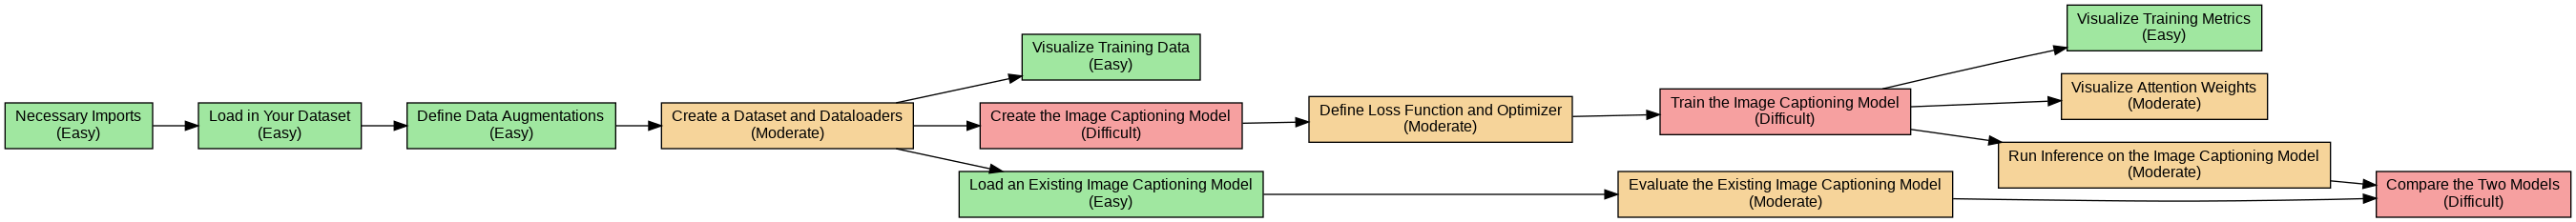

In [ ]:
# @title Image Captioning Tasks
# %%capture flowchart_output
# HIDDEN CELL
from graphviz import Digraph
from IPython.display import Image as IMG

def create_flowchart(output_filename='flowchart'):
    dot = Digraph(name='Simplified Object Detection', format='png')
    dot.attr(rankdir='LR')
    dot.attr('node', shape='box', style='filled', fontsize='12', fontname='Arial')

    dot.node('Imports', 'Necessary Imports\n(Easy)', fillcolor='#A0E7A0')

    dot.node('LoadData', 'Load in Your Dataset\n(Easy)', fillcolor='#A0E7A0')

    dot.node('AugmentData', 'Define Data Augmentations\n(Easy)', fillcolor='#A0E7A0')

    dot.node('DatasetDataloader', 'Create a Dataset and Dataloaders\n(Moderate)', fillcolor='#F6D49A')

    dot.node('VisualizeSample', 'Visualize Training Data\n(Easy)', fillcolor='#A0E7A0')
    dot.node('CreateModel', 'Create the Image Captioning Model\n(Difficult)', fillcolor='#F6A0A0')

    dot.node('Hyperparameters', 'Define Loss Function and Optimizer\n(Moderate)', fillcolor='#F6D49A')

    dot.node('TrainModel', 'Train the Image Captioning Model\n(Difficult)', fillcolor='#F6A0A0')

    dot.node('VisualizeTrain', 'Visualize Training Metrics\n(Easy)', fillcolor='#A0E7A0')
    dot.node('VisualizeAtt', 'Visualize Attention Weights\n(Moderate)', fillcolor='#F6D49A')
    dot.node('RunInference', 'Run Inference on the Image Captioning Model\n(Moderate)', fillcolor='#F6D49A')

    dot.node('LoadModel', 'Load an Existing Image Captioning Model\n(Easy)', fillcolor='#A0E7A0')

    dot.node('EvaluateModel', 'Evaluate the Existing Image Captioning Model\n(Moderate)', fillcolor='#F6D49A')

    dot.node('Comparison', 'Compare the Two Models\n(Difficult)', fillcolor='#F6A0A0')

    # Edges
    dot.edge('Imports', 'LoadData')

    dot.edge('LoadData', 'AugmentData')

    dot.edge('AugmentData', 'DatasetDataloader')

    dot.edge('DatasetDataloader', 'CreateModel')
    dot.edge('DatasetDataloader', 'VisualizeSample')

    dot.edge('CreateModel', 'Hyperparameters')
    dot.edge('Hyperparameters', 'TrainModel')
    dot.edge('TrainModel', 'VisualizeTrain')
    dot.edge('TrainModel', 'VisualizeAtt')
    dot.edge('TrainModel', 'RunInference')

    dot.edge('DatasetDataloader', 'LoadModel')
    dot.edge('LoadModel', 'EvaluateModel')
    dot.edge('RunInference', 'Comparison')
    dot.edge('EvaluateModel', 'Comparison')

    dot.render(output_filename, view=False)

create_flowchart('assignment1_flowchart')
IMG('assignment1_flowchart.png')

Each section of the Notebook will guide you through the task:

- `necessary imports`
- `data loading process`
- `defining data augmentations`
- `creating a dataset and dataloaders`
- `visualizing the training data`
- `creating a CNN model`
- `creating a FCN model`
- `defining a loss function and an optimizer`
- `creating a training and validation loop`
- `testing the models`
- `comparing results`
- `visualizing weights and feature maps`

The sections are there to guide you but you **do not have to follow them strictly**.

Copy this notebook to your drive (`File -> Save a copy in Drive`), edit it, and upload the final `.ipynb` file to [Canvas](https://canvas.elte.hu). If you are using this in **Google Colab**, save it as `.ipynb` and upload it, or share the public link. If you have your own machine with Jupyter installed, you can work there as well, as long as you save and upload the `.ipynb` file.

## **General Rules**
Please check all the requirements listed on **Canvas**, but here are some general rules:

- The model is **not expected to achieve high performance** but must perform better than random color guessing.
- Copying others' code will make you fail the assignment automatically, resulting in a **0**.
- Not submitting anything results in a **0**.
- Submitting something, as long as it is not an empty notebook, might result in a 1.
- **Deadline is November 25th Tuesday 11:59 PM** (strict, no late submission)
- Feel free to add more code cells as needed. But don't put code into external Python files.
- Please add your `name` and `Neptun ID` below.

`Good luck!`

**In order to get your grade for an assignment, you must defend it by answering questions during the designated practice time.**

## **Guidelines**
Please carefully read each cell of the notebook, as they contain guidelines to help you complete the assignments. While you don't have to follow them strictly, we believe that they provide enough help.

**Name:**  Nann Theint Kham Ko Ko
**Neptun ID:** LQOO56

## **0. Necessary Imports**
Import all the necessary packages for this assignment. **ONLY PYTORCH MODELS ARE ACCEPTED!**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import nltk
import torchvision
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchaudio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torchvision.models as models
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

import pandas as pd
import numpy as np
from collections import Counter
import random
import re
import time
from tqdm import tqdm
from collections import defaultdict
import json
import textwrap

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## **1. Data Loading Process**

For this assignment you will be using the [Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k) dataset, which contains **captions/descriptions** of different images.

<img src="https://user-images.githubusercontent.com/38347541/56469847-9faa0780-645c-11e9-822a-11a15bb56f5b.png" alt="1" border="0">

The best way to download this dataset is through `Kaggle`. First **create a token**, download it and upload it here. Follow [these](https://www.kaggle.com/discussions/general/74235) steps.

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nanntheintkhamkoko","key":"fef45dd4e6a1f09004cd871d519e14b2"}'}

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download -d 'adityajn105/flickr8k'

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 88% 931M/1.04G [00:00<00:00, 1.56GB/s]
100% 1.04G/1.04G [00:00<00:00, 1.56GB/s]


In [ ]:
! mkdir flickr
! unzip flickr8k.zip -d flickr

Streaming output truncated to the last 5000 lines.
  inflating: flickr/Images/2844846111_8c1cbfc75d.jpg  
  inflating: flickr/Images/2844963839_ff09cdb81f.jpg  
  inflating: flickr/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: flickr/Images/2845691057_d4ab89d889.jpg  
  inflating: flickr/Images/2845845721_d0bc113ff7.jpg  
  inflating: flickr/Images/2846037553_1a1de50709.jpg  
  inflating: flickr/Images/2846785268_904c5fcf9f.jpg  
  inflating: flickr/Images/2846843520_b0e6211478.jpg  
  inflating: flickr/Images/2847514745_9a35493023.jpg  
  inflating: flickr/Images/2847615962_c330bded6e.jpg  
  inflating: flickr/Images/2847859796_4d9cb0d31f.jpg  
  inflating: flickr/Images/2848266893_9693c66275.jpg  
  inflating: flickr/Images/2848571082_26454cb981.jpg  
  inflating: flickr/Images/2848895544_6d06210e9d.jpg  
  inflating: flickr/Images/2848977044_446a31d86e.jpg  
  inflating: flickr/Images/2849194983_2968c72832.jpg  
  inflating: flickr/Images/2850719435_221f15e951.jpg  
  inflating: f

## **2. Defining Augmentations**

When applying **augmentations** to the `Flickr8k` dataset, it is important to note that these transformations should be applied **only to the images** and not to the captions.

Ensure that your **data augmentation pipeline** includes:
- A **normalization step** to scale pixel values appropriately.
- A **tensor conversion step** to transform images into tensors for model compatibility.
- Additional **augmentations of your choice**, such as random cropping, flipping, or color jittering, to enhance model generalization.

```python
train_transforms = transforms.Compose([
            # Add Augmentations
])

test_transforms = transforms.Compose([
            # Add Augmentations
])
```

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5)
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## **3. Creating Datasets and Dataloaders**

To load the **Flickr8k** dataset, you need to create a **custom PyTorch** `Dataset` class that returns **images and their corresponding captions**. The captions should be **tokenized** before being returned.

Make sure to include special tokens in your tokenized captions:
- `sos` (Start of Sentence)
- `eos` (End of Sentence)
- `unk` (Unknown Token) for words outside the vocabulary.

It is recommended to build a **Vocabulary class** to store all the words in your dataset, as your model can only generate words that exist in this vocabulary. However, saving every word is unnecessary. A **common practice** is to include only words that appear **at least 5 times** across the entire dataset to reduce noise and improve model efficiency.

For the **DataLoader**, ensure that the **batch size** is appropriate so that it fits into memory. Set the **`shuffle`** parameter as follows:

- **Training & Validation DataLoaders:** `shuffle=True` (to randomize the order of samples)  
- **Test DataLoader:** `shuffle=False` (to maintain consistency in evaluation)

> **Note**: Remember that, a batch has **different examples**, and each example (caption) might have **different sizes**. Therefore, consider padding techniques for the captions.

```python
class FlickrDataset(Dataset):
    def __init__(self,):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        raise NotImplementedError
```

In [ ]:
class Vocabulary:
  '''
  Vocabulary class for handling text data.
  '''
  def __init__(self, freq_threshold=5):
    '''
    Args:
      freq_threshold (int): Minimum frequency threshold for inclusion in the vocabulary.
    '''

    self.freq_threshold = freq_threshold

    self.pad_token = "<PAD>"
    self.sos_token = "<SOS>"
    self.eos_token = "<EOS>"
    self.unk_token = "<UNK>"

    # initialize mapping with special tokens
    self.word2idx = {
        self.pad_token: 0,
        self.sos_token: 1,
        self.eos_token: 2,
        self.unk_token: 3
    }

    # reverse mapping
    self.idx2word = { idx : word for word, idx in self.word2idx.items() }

    # counter to track word frequency across the entire dataset
    self.word_freq = Counter()

  def build_vocabulary(self, caption_list):
    '''
    Build the vocabulary from a list of captions.
    Args:
      caption_list (list): List of captions.
    '''
    # accumulate frequencies
    for caption in caption_list:
      tokens = self.tokenize(caption)
      self.word_freq.update(tokens)

    # assign indices to words that pass the threshold
    idx = len(self.word2idx)
    for word, freq in self.word_freq.items():
      if freq >= self.freq_threshold:
        if word not in self.word2idx:
          self.word2idx[word] = idx
          self.idx2word[idx] = word
          idx += 1

    print(f"Vocabulary size: {len(self.word2idx)}")
    print(f"Words above threshold ({self.freq_threshold}): {len(self.word2idx) - 4}")

  def tokenize(self, caption):
    '''
    Tokenize a caption.
    Args:
      caption (str): Caption to be tokenized.
    '''
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    return caption.split()

  def encode(self, caption):
    '''
    Encode a caption into a list of indices.
    Args:
      caption (str): Caption to be encoded.
    '''
    tokens = self.tokenize(caption)
    indices = [self.word2idx.get(token, self.word2idx[self.unk_token])
                                 for token in tokens]
    return [self.word2idx[self.sos_token]] + indices + [self.word2idx[self.eos_token]]

  def decode(self, indices):
    '''
    Decode a list of indices into a caption.
    Args:
      indices (list): List of indices.
    '''
    tokens = [self.idx2word.get(idx, self.unk_token) for idx in indices]
    words = [w for w in tokens if w not in [self.pad_token, self.sos_token, self.eos_token]]
    return ' '.join(words)

  def __len__(self):
    return len(self.word2idx)

In [ ]:
class FlickrDataset(Dataset):
  '''
  Custom dataset class for the Flickr8k dataset.
  '''
  def __init__(self, images_dir, captions_file, vocab=None, transform=None, freq_threshold=5, split="train"):
    '''
    Args:
      images_dir (str): Path to the directory containing
      captions_file (str or pd.DataFrame): Path to the captions file or a DataFrame.
      vocab (Vocabulary): Vocabulary object.
    '''
    self.images_dir = images_dir
    self.transform = transform
    self.split = split

    if isinstance(captions_file, pd.DataFrame):
      self.df = captions_file.reset_index(drop=True)
    elif isinstance(captions_file, str):
      self.df = pd.read_csv(captions_file)
    else:
      raise ValueError("captions_file must be either a DataFrame or a string path")

    # vocabulary logic (if training, build a new vocab from scratch, otherwise, use existing training vocab)
    if vocab is None and split == "train":
      self.vocab = Vocabulary(freq_threshold=freq_threshold)
      all_captions = self.df['caption'].tolist()
      self.vocab.build_vocabulary(all_captions)
    else:
      self.vocab = vocab
      if vocab is None:
        raise ValueError("Vocabulary must be provided for validation/test sets")

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    '''
    Get a single sample data pair (image, caption) from the dataset.
    '''
    row = self.df.iloc[idx]
    caption = str(row['caption'])
    img_name = str(row['image'])

    img_path = os.path.join(self.images_dir, img_name)

    if not os.path.exists(img_path):
      raise ValueError(f"Image file not found: {img_path}")

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    caption_encoded = torch.tensor(self.vocab.encode(caption), dtype=torch.long)

    return image, caption_encoded, img_name


In [ ]:
class CollateFunction:
  '''
  Custom collate function for batching data.
  '''
  def __init__(self, pad_idx):
    self.pad_idx = pad_idx

  def __call__(self, batch):
    '''
    Collate a batch of data.
    Args:
      batch: A list of tuples (image, caption).
    '''
    images, captions, img_names = zip(*batch)

    images = torch.stack(images, dim=0)

    lengths = [len(cap) for cap in captions]

    # pad the captions so they all equal the length of the longest caption in this batch
    captions_padded = pad_sequence(captions, batch_first=True, padding_value=self.pad_idx)

    return images, captions_padded, lengths, img_names

In [ ]:
def split_dataset(captions_file, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):
  '''
  Split the dataset into training, validation, test
  '''
  df = pd.read_csv(captions_file)

  # get unique image filenames to ensure all 5 captions for one image stay in the same set
  unique_images = df['image'].unique()
  # shuffle images to ensure random distribution
  np.random.seed(random_seed)
  np.random.shuffle(unique_images)

  # calculate split indices and slice the unique image list
  n_images = len(unique_images)
  train_end = int(train_ratio * n_images)
  val_end = train_end + int(val_ratio * n_images)

  train_images = unique_images[:train_end]
  val_images = unique_images[train_end:val_end]
  test_images = unique_images[val_end:]

  # filter the original dataframe based on the selected images
  train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
  val_df = df[df['image'].isin(val_images)].reset_index(drop=True)
  test_df = df[df['image'].isin(test_images)].reset_index(drop=True)

  print(f"Dataset Split:")
  print(f"    Train: {len(train_images)} images, {len(train_df)} captions")
  print(f"    Validation: {len(val_images)} images, {len(val_df)} captions")
  print(f"    Test: {len(test_images)} images, {len(test_df)} captions")

  train_df.to_csv("flickr/train.csv", index=False)
  val_df.to_csv("flickr/val.csv", index=False)
  test_df.to_csv("flickr/test.csv", index=False)

  return train_df, val_df, test_df

In [ ]:
def create_dataloaders(images_dir, train_df, val_df, test_df, train_transforms, test_transforms, batch_size=32, num_workers=2, freq_threshold=5):
  '''
  Create dataloaders for training, validation, and test sets.
  '''
  # initialize training dataset
  train_dataset = FlickrDataset(
      images_dir=images_dir,
      captions_file=train_df,
      vocab=None,
      transform=train_transforms,
      freq_threshold=freq_threshold,
      split="train"
  )

  vocab = train_dataset.vocab

  # initialize validation and test dataset
  val_dataset = FlickrDataset(
      images_dir=images_dir,
      captions_file=val_df,
      vocab=vocab,
      transform=test_transforms,
      freq_threshold=freq_threshold,
      split="val"
  )

  test_dataset = FlickrDataset(
      images_dir=images_dir,
      captions_file=test_df,
      vocab=vocab,
      transform=test_transforms,
      freq_threshold=freq_threshold,
      split="test"
  )

  # prepare batching logic
  pad_idx = vocab.word2idx[vocab.pad_token]
  collate_fn = CollateFunction(pad_idx)

  # create dataloaders
  train_loader = DataLoader(
      dataset=train_dataset,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      collate_fn=collate_fn,
      pin_memory=True
  )

  val_loader = DataLoader(
      dataset=val_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      collate_fn=collate_fn,
      pin_memory=True
  )

  test_loader = DataLoader(
      dataset=test_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      collate_fn=collate_fn,
      pin_memory=True
  )

  return train_loader, val_loader, test_loader, vocab, train_dataset, val_dataset, test_dataset

In [ ]:
images = "flickr/Images"
captions = "flickr/captions.txt"

train_df, val_df, test_df = split_dataset(captions)

train_loader, val_loader, test_loader, vocab, train_dataset, val_dataset, test_dataset = create_dataloaders(
    images_dir=images,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    train_transforms=train_transforms,
    test_transforms=test_transforms,
    batch_size=32,
    num_workers=2,
    freq_threshold=5
)

print(f"\nVocabulary size: {len(vocab)}")
print(f"PAD token index: {vocab.word2idx[vocab.pad_token]}")
print(f"SOS token index: {vocab.word2idx[vocab.sos_token]}")
print(f"EOS token index: {vocab.word2idx[vocab.eos_token]}")
print(f"UNK token index: {vocab.word2idx[vocab.unk_token]}")

Dataset Split:
    Train: 5663 images, 28315 captions
    Validation: 1213 images, 6065 captions
    Test: 1215 images, 6075 captions
Vocabulary size: 2493
Words above threshold (5): 2489

Vocabulary size: 2493
PAD token index: 0
SOS token index: 1
EOS token index: 2
UNK token index: 3


## **4.1 Visualizing Training Data**

To visualize the training data, extract a batch from the training `DataLoader` and plot the **input-target** pairs using `Matplotlib` or `Seaborn`. Ensure that at least **8 pairs** are displayed for a clear representation.

Make sure to **visualize the original and the tokenized caption** as well!

```python
def visualize_batch():
  raise NotImplementedError
```

In [ ]:
def denormalize_image(image, mean=[0.485, 0.456, 0.405], std=[0.229, 0.224, 0.225]):
  '''
  Denormalize an image tensor.

  Args:
    image (torch.Tensor): Input image tensor of shape (C, H, W).
    mean (list): Mean values for normalization.
    std (list): Standard deviation values for normalization.

  Returns:
    img: Denormalized image tensor of shape (H, W, C).
  '''
  img = image.clone()

  for t, m, s in zip(img, mean, std):
    t.mul_(s).add_(m)

  img = torch.clamp(img, 0, 1)

  img = img.numpy().transpose((1, 2, 0))

  return img

In [ ]:
def visualize_batch(dataloader, vocab, num_samples=8, fig_size=(20, 12)):
  images, captions, lengths, img_names = next(iter(dataloader))

  num_samples = min(num_samples, len(images))

  fig, axes = plt.subplots(num_samples, 1, figsize=fig_size)

  if num_samples == 1:
    axes = [axes]

  fig.suptitle('Training Data Visualization - List View',
                 fontsize=16, fontweight='bold', y=0.995)

  for idx in range(num_samples):
    image = images[idx]
    caption_encoded = captions[idx]
    img_name = img_names[idx]

    img_display = denormalize_image(image.cpu())

    caption_length = lengths[idx]
    caption_tokens = caption_encoded[:caption_length].cpu().numpy()
    caption_text = vocab.decode(caption_tokens)

    tokenized_repr = ' '.join([f"{vocab.idx2word[idx.item()]}({idx.item()})"
                                   for idx in caption_encoded[:caption_length]])

    axes[idx].imshow(img_display)
    axes[idx].axis('off')

    axes[idx].set_title(
        f"Image: {img_name}\n"
        f"Original Caption: {caption_text}\n"
        f"Tokenized: {tokenized_repr[:150]}{'...' if len(tokenized_repr) > 150 else ''}",
        fontsize=10,
        wrap=True,
        loc='left'
    )

  plt.tight_layout()
  plt.show()

  print(f"\n{'-'*80}")
  print(f"Batch Statistics")
  print(f"    Batch Size: {len(images)}")
  print(f"    Image Shape: {images[0].shape}")
  print(f"    Caption Length: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")
  print(f"    Padded Caption Shape: {captions.shape}")
  print(f"{'-'*80}\n")


In [ ]:
def visualize_batch_grid(dataloader, vocab, num_samples=8, cols=4, fig_size=(20, 12)):
  images, captions, lengths, img_names = next(iter(dataloader))

  num_samples = min(num_samples, len(images))

  rows = (num_samples + cols - 1) // cols

  fig, axes = plt.subplots(rows, cols, figsize=fig_size)
  axes = axes.flatten() if num_samples > 1 else [axes]

  fig.suptitle('Training Data Visualization - Grid View',
                 fontsize=16, fontweight='bold', y=0.995)

  for idx in range(num_samples):
    image = images[idx]
    caption_encoded = captions[idx]
    img_name = img_names[idx]

    img_display = denormalize_image(image.cpu())

    caption_length = lengths[idx]
    caption_tokens = caption_encoded[:caption_length].cpu().numpy()
    caption_text = vocab.decode(caption_tokens)

    axes[idx].imshow(img_display)
    axes[idx].axis('off')

    axes[idx].set_title(
        f"Image: {img_name}\n"
        f"{caption_text[:80]}{'...' if len(caption_text) > 80 else ''}",
        fontsize=10,
        wrap=True
    )

  for idx in range(num_samples, len(axes)):
    axes[idx].axis('off')


  plt.tight_layout()
  plt.show()

In [ ]:
def visualize_tokenization_detail(dataloader, vocab, num_samples=3):
  images, captions, lengths, img_names = next(iter(dataloader))

  num_samples = min(num_samples, len(images))

  for idx in range(num_samples):
    caption_encoded = captions[idx]
    caption_length = lengths[idx]
    img_name = img_names[idx]

    print(f"Sample {idx + 1}: {img_name}")
    print(f"{'-'*80}")

    caption_tokens_no_specials = []
    for idx in range(caption_length):
      token_idx = caption_encoded[idx].item()
      token_word = vocab.idx2word[token_idx]
      caption_tokens_no_specials.append(token_word)

    original_words = [w for w in caption_tokens_no_specials
                      if w not in [vocab.eos_token, vocab.sos_token]]
    print(f"Original Caption: {' '.join(original_words)}")

    print(f"\nTokenized Representation:")
    token_details = []
    for idx in range(caption_length):
      token_idx = caption_encoded[idx].item()
      token_word = vocab.idx2word[token_idx]
      token_details.append(f"{token_word}({token_idx})")
    print(" ".join(token_details))

    if caption_length < len(caption_encoded):
      num_padding = len(caption_encoded) - caption_length
      print(f"\nPadding: {num_padding} <PAD>[{vocab.word2idx[vocab.pad_token]}] tokens")

    print(f"\nStatistics:")
    print(f"    Caption Length (with SOS, EOS): {caption_length}")
    print(f"    Number of Content Words: {len(original_words)}")
    print(f"    Padded Length: {len(caption_encoded)}")

    unk_count = sum(1 for i in range(caption_length) if caption_encoded[i].item() == vocab.word2idx[vocab.unk_token])
    if unk_count > 0:
      print(f"    Number of Unknown Words: {unk_count}")

    print(f"{'-'*80}\n")


In [ ]:
def visualize_vocabulary_stats(vocab):
  print(f"\n{'-'*80}")
  print(f"Vocabulary Statistics")
  print(f"{'-'*80}")
  print(f"Total Vocabulary Size: {len(vocab)}")
  print(f"     Special Tokens: 4({vocab.pad_token}, {vocab.sos_token}, {vocab.eos_token}, {vocab.unk_token})")
  print(f"     Content Words: {len(vocab) - 4}")
  print(f"\nFrequency Threshold: {vocab.freq_threshold}")


  if vocab.word_freq:
    print(f"\nTop 20 most frequent words:")
    most_common = vocab.word_freq.most_common(20)
    for word, freq in most_common:
      print(f"    {word:15s}: {freq:4d} times")

  if vocab.word_freq:
    frequencies = list(vocab.word_freq.values())

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(frequencies, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(vocab.freq_threshold, color='red', linestyle='--',
                label=f'Frequency Threshold ({vocab.freq_threshold})')
    plt.xlabel('Frequency')
    plt.ylabel('Number of Words')
    plt.title('Frequency Distribution of Words')
    plt.legend()
    plt.yscale('log')

    plt.subplot(1, 2, 2)
    sorted_freq = sorted(frequencies, reverse=True)
    plt.plot(range(len(sorted_freq)), sorted_freq)
    plt.axvline(vocab.freq_threshold, color='red', linestyle='--',
                label=f'Frequency Threshold ({vocab.freq_threshold})')
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.title('Rank-Frequency Plot')
    plt.legend()
    plt.yscale('log')

    plt.tight_layout()
    plt.show()

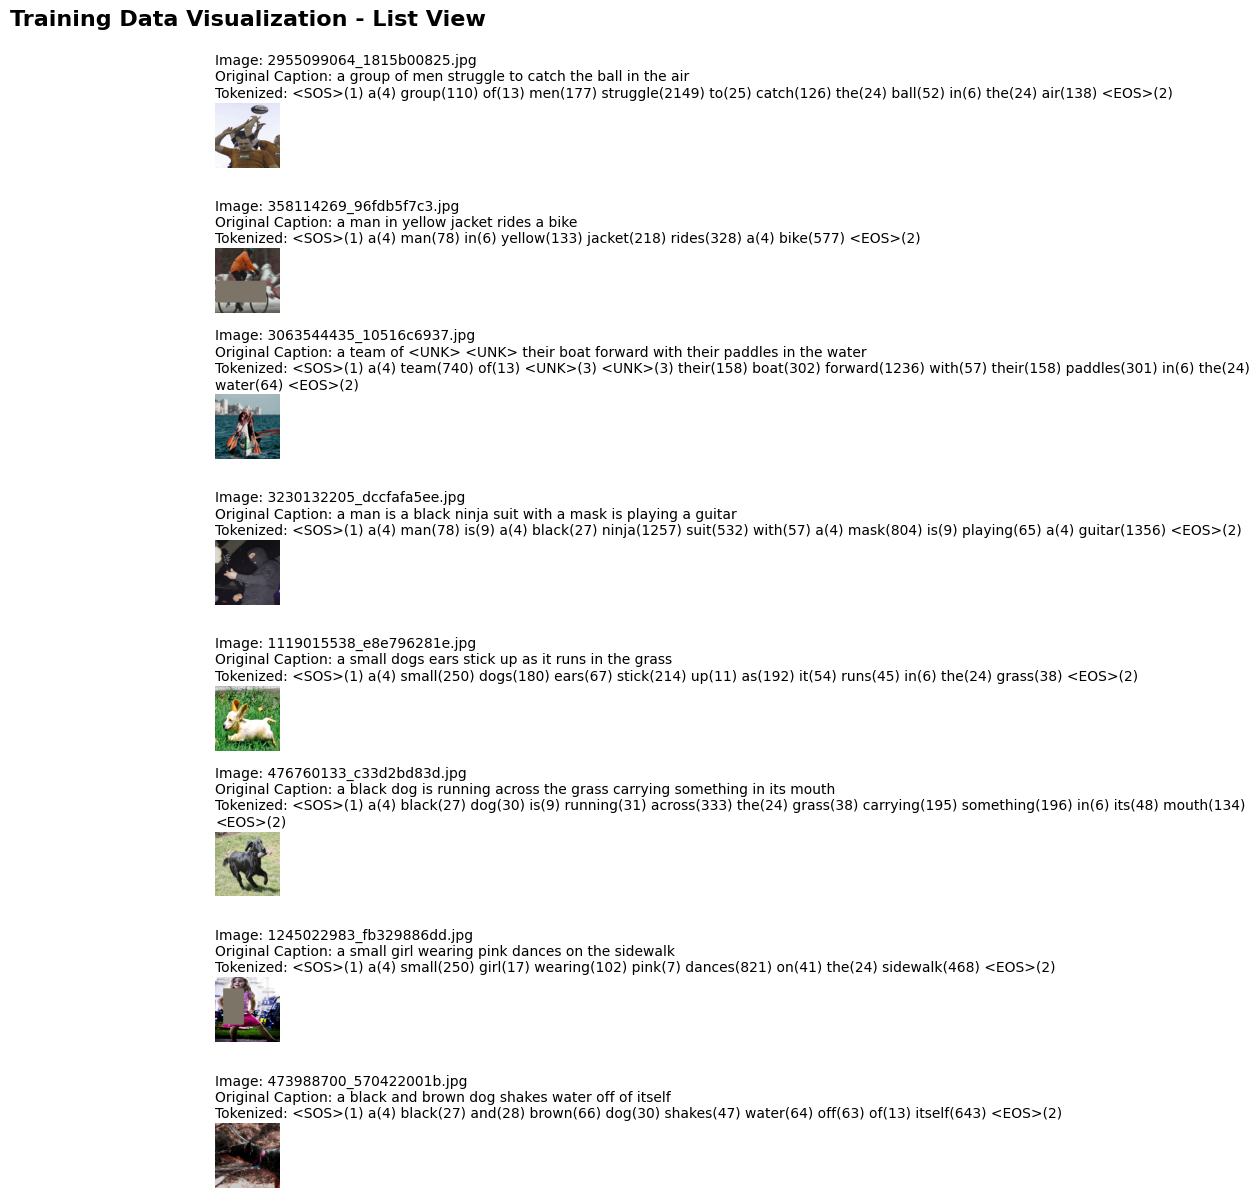


--------------------------------------------------------------------------------
Batch Statistics
    Batch Size: 32
    Image Shape: torch.Size([3, 224, 224])
    Caption Length: min=7, max=21, avg=12.47
    Padded Caption Shape: torch.Size([32, 21])
--------------------------------------------------------------------------------



In [ ]:
visualize_batch(train_loader, vocab, num_samples=8)

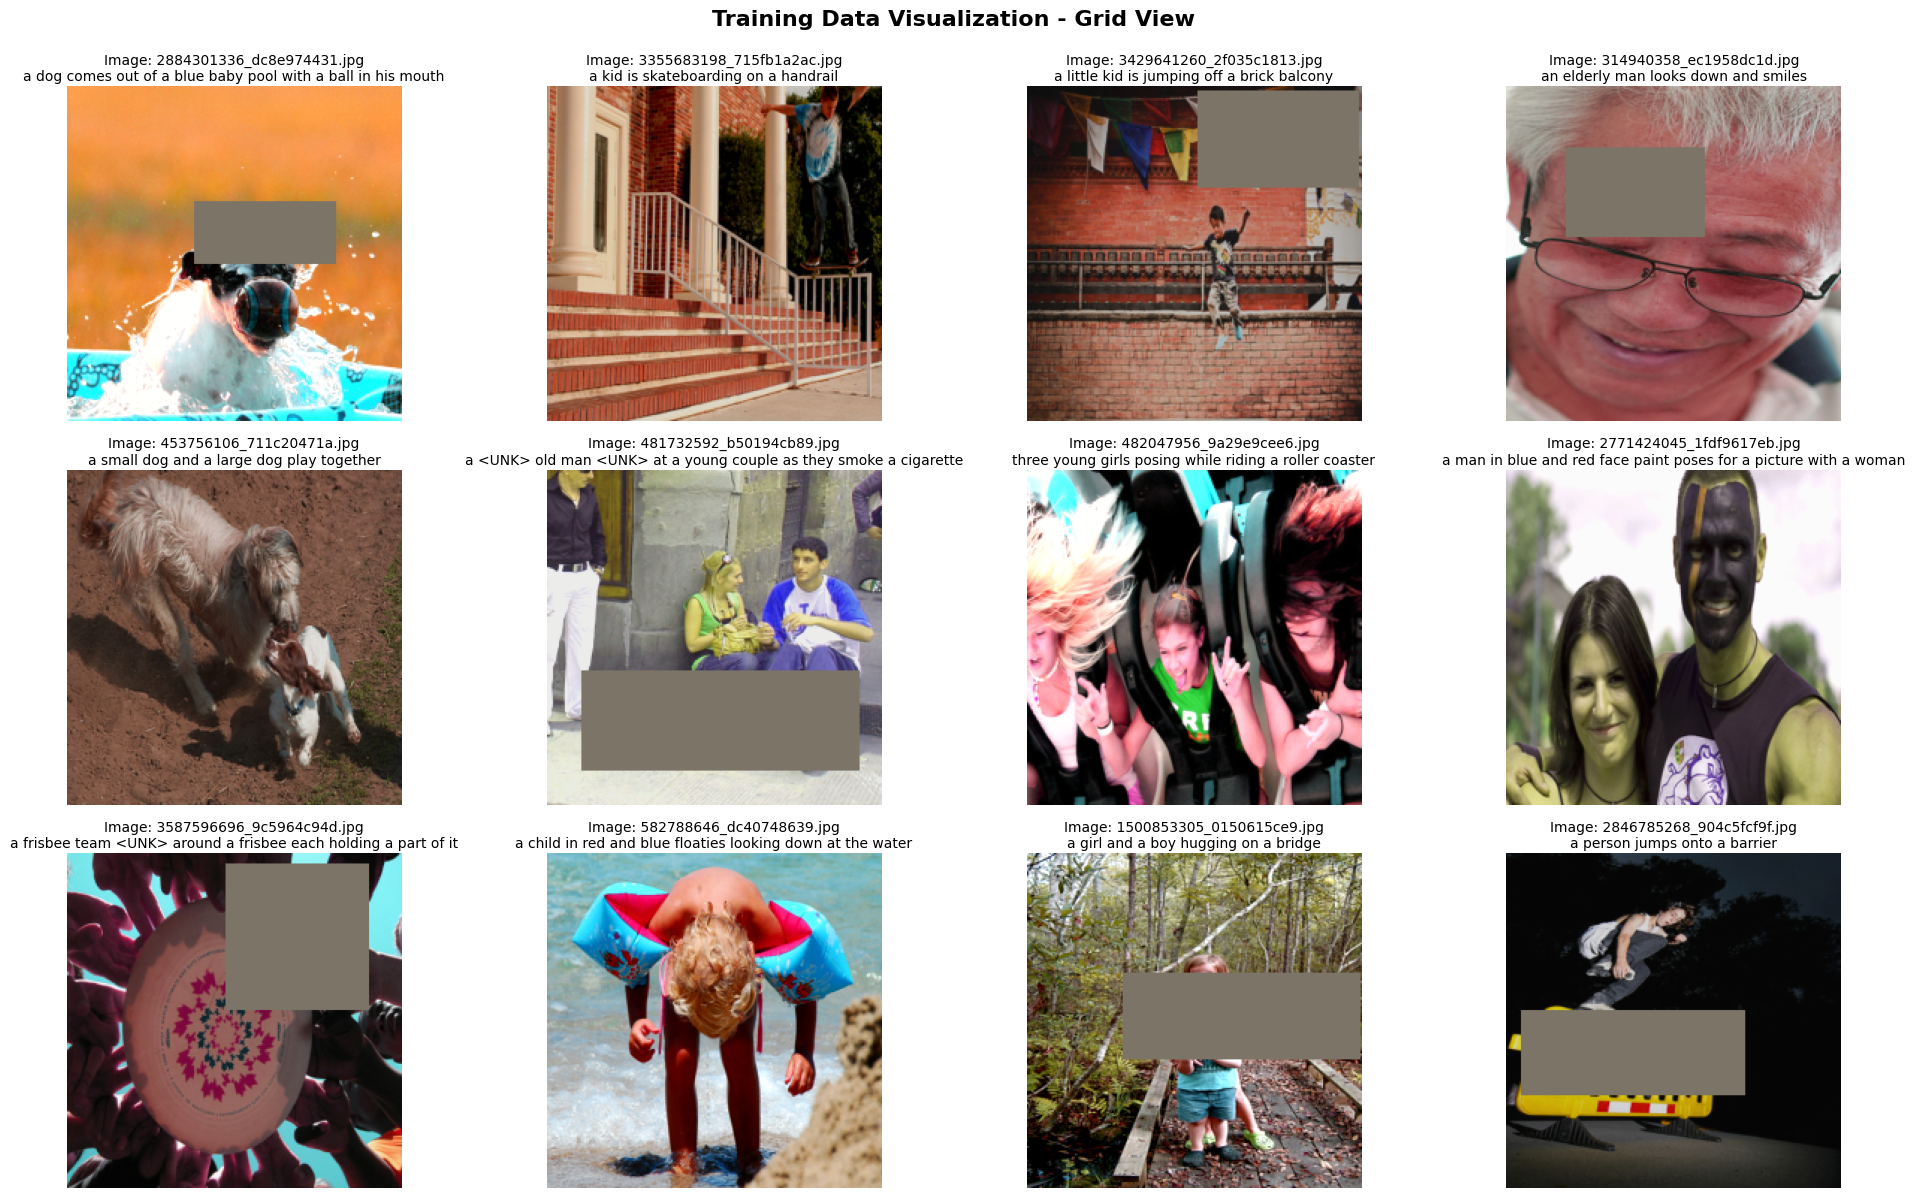

In [ ]:
visualize_batch_grid(train_loader, vocab, num_samples=12, cols=4)

In [ ]:
print("\n" + "-" * 80)
print("TOKENIZATION DETAILS")
print("-" * 80)
visualize_tokenization_detail(train_loader, vocab, num_samples=3)


--------------------------------------------------------------------------------
TOKENIZATION DETAILS
--------------------------------------------------------------------------------
Sample 1: 2290330500_e7bdaa58e1.jpg
--------------------------------------------------------------------------------
Original Caption: a young girl is practicing volleyball in a grass field

Tokenized Representation:
<SOS>(1) a(4) young(82) girl(17) is(9) practicing(1262) volleyball(1227) in(6) a(4) grass(38) field(129) <EOS>(2)

Padding: 5 <PAD>[0] tokens

Statistics:
    Caption Length (with SOS, EOS): 12
    Number of Content Words: 10
    Padded Length: 17
--------------------------------------------------------------------------------

Sample 2: 3251906388_c09d44340e.jpg
--------------------------------------------------------------------------------
Original Caption: two poodles playing <UNK>

Tokenized Representation:
<SOS>(1) two(176) poodles(1696) playing(65) <UNK>(3) <EOS>(2)

Padding: 11 <PAD>[


--------------------------------------------------------------------------------
VOCABULARY ANALYSIS
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Vocabulary Statistics
--------------------------------------------------------------------------------
Total Vocabulary Size: 2493
     Special Tokens: 4(<PAD>, <SOS>, <EOS>, <UNK>)
     Content Words: 2489

Frequency Threshold: 5

Top 20 most frequent words:
    a              : 44491 times
    in             : 13247 times
    the            : 12864 times
    on             : 7588 times
    is             : 6599 times
    and            : 6201 times
    dog            : 5600 times
    with           : 5421 times
    man            : 5100 times
    of             : 4669 times
    two            : 3948 times
    white          : 2864 times
    black          : 2704 times
    boy            : 2529 times
    are            : 245

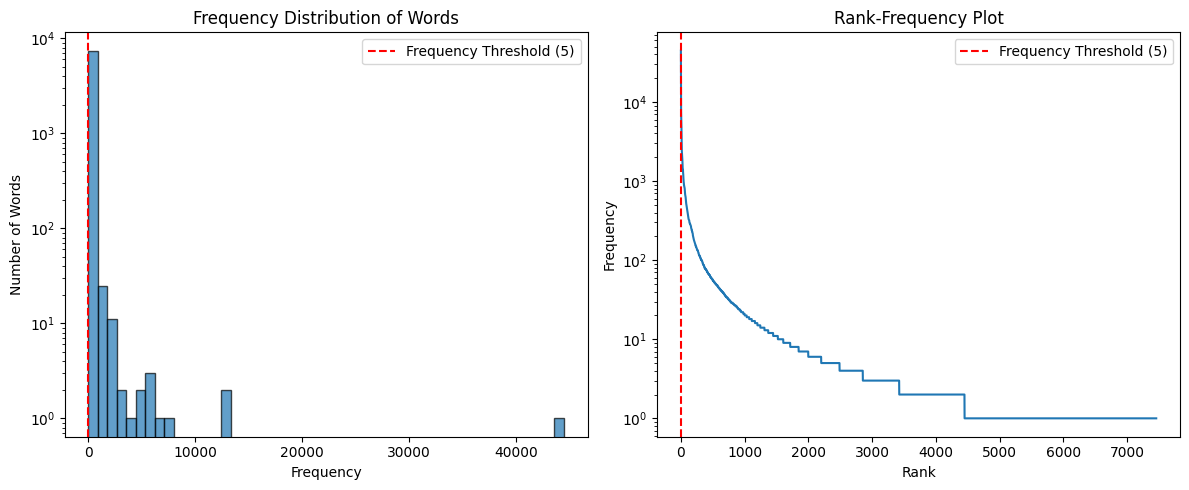

In [ ]:
print("\n" + "-" * 80)
print("VOCABULARY ANALYSIS")
print("-" * 80)
visualize_vocabulary_stats(vocab)

## **4.2 Creating the Image Captioning Model**

For this assignment, **you are required to create your own custom image captioning model** and **compare its performance** with an existing pre-trained model.

---

### **Encoder-Attention-Decoder Architecture**

Your model should follow an **Encoder-Attention-Decoder** structure with the following components:

- The **Encoder** processes images to extract meaningful features. You can either design a **custom convolutional architecture** or use a **pre-trained model** like *ResNet*, but **fine-tuning is required** to adapt the features to the captioning task.
- The **Attention Layer** acts as an interface between the encoder and decoder. It leverages the extracted image features to compute **attention scores**, helping the decoder focus on relevant parts of the image during caption generation. For simplicity, use **Linear layers** to implement the attention mechanism.
- The **Decoder** is a sequence-based model (e.g., *LSTM*) that processes the image features and generates captions sequentially.

---

#### **Extra Credit Opportunity**
- Additional points will be awarded for implementing either a **Vision Transformer (ViT) encoder** or a **Transformer-based decoder** instead of an LSTM.

Here is an example of something similar to what we want to create:
<img src="https://drive.google.com/thumbnail?id=1wdddaLit7iEyCcVy5bS505NiYzL6c-4x&sz=w1000">

```python
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        return NotImplementedError

    def forward(self, images):
        return NotImplementedError
```

```python
class Attention(nn.Module):
    def __init__(self, encoder_dim,decoder_dim,attention_dim):
        super(Attention, self).__init__()
        return NotImplementedError

    def forward(self, features, hidden_state):
        return NotImplementedError
```

```python
class Decoder(nn.Module):
    def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim):
        return NotImplementedError

    def forward(self, features, captions):
        return NotImplementedError
```
```python
class EncoderDecoder(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim, encoder_dim,decoder_dim):
        return NotImplementedError

    def forward(self, images, captions):
        return NotImplementedError
```

In [ ]:
class Encoder(nn.Module):
  '''
  Encoder module for image captioning.
  '''
  def __init__(self, encoder_dim=2048, fine_tune=True):
    '''
    Args:
      encoder_dim (int): Dimensionality of the encoder features.
      fine_tune (bool): Whether to fine-tune the encoder.
    '''
    super(Encoder, self).__init__()

    resnet = models.resnet50(pretrained=True)

    # remove last 2 layers
    modules = list(resnet.children())[:-2]
    self.resnet = nn.Sequential(*modules)

    self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    self.encoder_dim = encoder_dim
    self.fine_tune(fine_tune)

  def forward(self, images):
    '''
    Args:
      images (torch.Tensor): Input images of shape (batch_size, 3, 256, 256).
    Returns:
      features: Encoded features of shape (batch_size, encoder_dim, 14, 14).
    '''
    with torch.set_grad_enabled(self.fine_tuning):
      features = self.resnet(images)

    features = self.adaptive_pool(features)

    batch_size = features.size(0)

    # rearrange tensor and flatten image pixels
    features = features.permute(0, 2, 3, 1)
    features = features.view(batch_size, -1, self.encoder_dim)

    return features

  def fine_tune(self, fine_tune=True):
    '''
    Freeze or unfreeze the encoder layers.
    '''
    self.fine_tuning = fine_tune
    for param in self.resnet.parameters():
      param.requires_grad = fine_tune


In [ ]:
class Attention(nn.Module):
  '''
  Attention layer for image captioning.
  '''
  def __init__(self, encoder_dim, decoder_dim, attention_dim):
    '''
    Args:
      encoder_dim (int): Dimensionality of the encoder features.
      decoder_dim (int): Dimensionality of the decoder features.
      attention_dim (int): Dimensionality of the attention features.
    '''
    super(Attention, self).__init__()

    self.encoder_att = nn.Linear(encoder_dim, attention_dim)
    self.decoder_att = nn.Linear(decoder_dim, attention_dim)
    self.full_att = nn.Linear(attention_dim, 1)

    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, features, hidden_state):
    '''
    Args:
      features (torch.Tensor): Encoded features of shape (batch_size, num_pixels, encoder_dim).
      hidden_state: Hidden state of the decoder of shape (batch_size, decoder_dim).
    '''
    att1 = self.encoder_att(features)
    att2 = self.decoder_att(hidden_state)
    att = self.full_att(self.relu(att1 + att2.unsqueeze(1)))

    alpha = self.softmax(att.squeeze(2))

    attention_weighted_encoding = (features * alpha.unsqueeze(2)).sum(dim=1)

    return attention_weighted_encoding, alpha

In [ ]:
class Decoder(nn.Module):
  '''
  Decoder module for image captioning.
  '''
  def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim, drop_out=0.5):
    super(Decoder, self).__init__()

    self.vocab_size = vocab_size
    self.attention_dim = attention_dim
    self.decoder_dim = decoder_dim

    self.attention = Attention(encoder_dim, decoder_dim, attention_dim)

    self.embedding = nn.Embedding(vocab_size, embed_size)
    self.dropout = nn.Dropout(p=drop_out)

    self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, decoder_dim, bias=True)

    # Layers to initialize Hidden (h) and Cell (c) states from the image mean
    self.init_h = nn.Linear(encoder_dim, decoder_dim)
    self.init_c = nn.Linear(encoder_dim, decoder_dim)

    # Learnable gate to decide how much to look at the image vs the word history
    self.f_beta = nn.Linear(decoder_dim, encoder_dim)
    self.sigmoid = nn.Sigmoid()

    self.fc = nn.Linear(decoder_dim, vocab_size)

    self.init_weights()

  def init_weights(self):
    '''
    Initialize weights for the decoder.
    '''
    self.embedding.weight.data.uniform_(-0.1, 0.1)
    self.fc.bias.data.fill_(0)
    self.fc.weight.data.uniform_(-0.1, 0.1)

  def init_hidden_state(self, features):
    '''
    Initialize the hidden state for the decoder.
    '''
    mean_features = features.mean(dim=1)
    h = self.init_h(mean_features)
    c = self.init_c(mean_features)

    return h, c

  def forward(self, features, captions, length):
    '''
    Args:
      features (torch.Tensor): Encoded features of shape (batch_size, num_pixels, encoder_dim).
      captions (torch.Tensor): Ground truth captions of shape (batch_size, max_caption_length).
      length (list): List of caption lengths for each batch.
    '''
    # sort by length
    batch_size = features.size(0)
    vocab_size = self.vocab_size

    lengths = torch.tensor(length)
    lenghts, sort_idx = lengths.sort(0, descending=True)
    features = features[sort_idx]
    captions = captions[sort_idx]

    # embeddings
    embeddings = self.embedding(captions)

    # initialize LSTM State
    h, c = self.init_hidden_state(features)

    decode_lengths = (lengths - 1).tolist()

    predictions = torch.zeros(batch_size, max(decode_lengths), vocab_size).to(features.device)
    alphas = torch.zeros(batch_size, max(decode_lengths), features.size(1)).to(features.device)

    # generation loop
    for t in range(max(decode_lengths)):
      batch_size_t = sum([l > t for l in decode_lengths])

      attention_weighted_encoding, alpha = self.attention(features[:batch_size_t], h[:batch_size_t])

      gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
      attention_weighted_encoding = gate * attention_weighted_encoding

      lstm_input = torch.cat((embeddings[:batch_size_t, t, :], attention_weighted_encoding), dim=1)

      h, c = self.lstm_cell(lstm_input, (h[:batch_size_t], c[:batch_size_t]))

      preds = self.fc(self.dropout(h))

      predictions[:batch_size_t, t, :] = preds
      alphas[:batch_size_t, t, :] = alpha

    return predictions, alphas, captions, decode_lengths, sort_idx

In [ ]:
class EncoderDecoder(nn.Module):
  def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim, drop_out=0.5, fine_tune_encoder=True):
    '''
    Args:
      embed_size (int): Dimensionality of the word embeddings.
      vocab_size (int): Size of the vocabulary.
      attention_dim (int): Dimensionality of the attention layer.
      encoder_dim (int): Dimensionality of the encoder features.
      decoder_dim (int): Dimensionality of the decoder.
      drop_out (float): Dropout probability.
      fine_tune_encoder (bool): Whether to fine-tune the encoder.
    '''
    super(EncoderDecoder, self).__init__()

    self.encoder = Encoder(encoder_dim, fine_tune=fine_tune_encoder)
    self.decoder = Decoder(
        embed_size=embed_size,
        vocab_size=vocab_size,
        attention_dim=attention_dim,
        encoder_dim=encoder_dim,
        decoder_dim=decoder_dim,
        drop_out=drop_out
    )

  def forward(self, images, captions, lengths):
    '''
    Forward pass of the EncoderDecoder model.
    '''
    features = self.encoder(images)
    predictions, alphas, captions, decode_lengths, sort_idx = self.decoder(features, captions, lengths)

    return predictions, alphas, captions, decode_lengths, sort_idx

In [ ]:
embed_size = 512
attention_dim = 512
encoder_dim = 2048
decoder_dim = 512
dropout = 0.65

model = EncoderDecoder(
    embed_size=embed_size,
    vocab_size=len(vocab),
    attention_dim=attention_dim,
    encoder_dim=encoder_dim,
    decoder_dim=decoder_dim,
    drop_out=dropout,
    fine_tune_encoder=True
).to(device)

print("="*80)
print("MODEL ARCHITECTURE")
print("="*80)
print(f"Vocabulary Size: {len(vocab)}")
print(f"Embedding Size: {embed_size}")
print(f"Encoder Dimension: {encoder_dim}")
print(f"Decoder Dimension: {decoder_dim}")
print(f"Attention Dimension: {attention_dim}")
print(f"Dropout: {dropout}")
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*80)


print("\nTesting model with sample batch...")
sample_images, sample_captions, sample_lengths, _ = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_captions = sample_captions.to(device)

with torch.no_grad():
  predictions, alphas, _, decode_lengths, _ = model(sample_images, sample_captions, sample_lengths)
  print(f"Input images shape: {sample_images.shape}")
  print(f"Input captions shape: {sample_captions.shape}")
  print(f"Predictions shape: {predictions.shape}")
  print(f"Alphas shape: {alphas.shape}")
  print("\n✓ Model test successful!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 41.1MB/s]


MODEL ARCHITECTURE
Vocabulary Size: 2493
Embedding Size: 512
Encoder Dimension: 2048
Decoder Dimension: 512
Attention Dimension: 512
Dropout: 0.65

Total Parameters: 36,819,966
Trainable Parameters: 36,819,966

Testing model with sample batch...
Input images shape: torch.Size([32, 3, 224, 224])
Input captions shape: torch.Size([32, 16])
Predictions shape: torch.Size([32, 15, 2493])
Alphas shape: torch.Size([32, 15, 196])

✓ Model test successful!


## **5. Defining Loss Function and Optimizer**

**Loss Functions and their options:**

In an **image captioning task**, the model generates a sequence of words conditioned on an image. This involves both **sequence generation (language modeling)** and **image understanding**, making loss selection crucial for effective training. The primary loss function should optimize **word prediction** while ensuring **grammatical correctness and semantic coherence**.

Since our task involves **predicting discrete word tokens**, we typically use **sequence-based loss functions**, but we can also explore loss functions that account for **semantic meaning** and **alignment**.

---

### **a. Cross-Entropy Loss (Standard Sequence Prediction Loss)**  
The most common loss for text generation tasks is **Cross-Entropy Loss**, which measures the difference between the **predicted word probability distribution** and the **true word** in the sequence. It is computed as:

$$
\mathcal{L}_{CE} = -\sum_{t=1}^{T} y_t \log(\hat{y}_t)
$$

where:
- $T $ is the sequence length (number of words in the caption),
- $ y_t $ is the **ground truth word** (one-hot encoded),
- $ \hat{y}_t $ is the **predicted probability** of that word.

- **Pros:** Simple, well-established for text generation tasks, easy to implement.
- **Cons:** Treats each word prediction independently, ignoring sentence-level meaning, but useful during `teacher forcing`.

---

### **b. CIDER Loss (Reinforcement Learning-Based Caption Quality Loss)**  
Cross-Entropy loss focuses on **token-level** accuracy, but it does not capture **sentence-level fluency and meaning**. CIDER (Consensus-based Image Description Evaluation) helps optimize captions towards human-like descriptions.

$$
\mathcal{L}_{CIDEr} = 1 - CIDEr(\hat{Y}, Y)
$$

where $ CIDEr(\hat{Y}, Y) $ measures how similar the generated caption $ \hat{Y} $ is to multiple reference captions $ Y $.

- **Pros:** Optimizes for caption similarity to human references, improves fluency. Best suited for **fine-tuning after pretraining with Cross-Entropy** Loss.
- **Cons:** Harder to optimize, requires reinforcement learning.

---

### **c. Reinforcement Learning-Based Loss (REINFORCE with Self-Critical Sequence Training - SCST)**  
Since captioning is **sequential**, we can treat it as a reinforcement learning problem. Instead of directly predicting words, we train the model to maximize **rewards** (e.g., BLEU or CIDEr scores). This is done using the **REINFORCE** algorithm:

$$
\mathcal{L}_{RL} = - (r(\hat{Y}) - r(\bar{Y})) \sum_{t=1}^{T} \log P(y_t | y_{1:t-1}, X)
$$

where:
- $ r(\hat{Y}) $ is the reward for the generated caption,
- $ r(\bar{Y}) $ is the baseline reward (e.g., score from a greedy decoder).

- **Pros:** Optimizes **sentence-level metrics** instead of per-word accuracy, leading to better captions.  
- **Cons:** Computationally expensive, requires careful tuning.   

---

[PyTorch Documentation](https://pytorch.org/docs/stable/nn.html#loss-functions)

---

**Optimizers and their options:**

There are some pre-built [Optimizers in PyTorch](https://pytorch.org/docs/stable/optim.html), they are sufficient in most cases, especially if their parameters are well set. The two most well-known are Adam (AdamW) and SGD, both of which originate from Gradient Descent, which we implemented earlier.

* **S**tochastic **G**radient **D**escent ([SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html))
* **ADA**ptive **M**oment optimizer ([ADAM](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
* [A good general overview](https://www.ruder.io/optimizing-gradient-descent/)

In [ ]:
class LabelSmoothingCrossEntropy(nn.Module):
  '''
  Applies label smoothing to the cross-entropy loss.
  '''
  def __init__(self, eps=0.1, ignore_index=0):
    '''
    Args:
      eps (float): Label smoothing factor.
      ignore_index (int): Index to ignore during loss calculation.
    '''
    super().__init__()
    self.eps = eps
    self.ignore_index = ignore_index

  def forward(self, preds, targets, decode_lengths):
    '''
    Forward pass of the LabelSmoothingCrossEntropy loss.

    Args:
      preds (torch.Tensor): Predicted logits of shape (batch_size, seq_len, vocab_size).
      targets (torch.Tensor): Ground truth labels
      decode_lengths (list): List of sequence lengths for each batch

    Returns:
      torch.Tensor: Scalar loss value.
    '''
    # sort data by length
    sorted_lengths, sorted_idx = torch.tensor(decode_lengths).sort(descending=True)
    preds   = preds[sorted_idx]
    targets = targets[sorted_idx]

    # shift target
    targets = targets[:, 1:]

    # pack sequence
    preds   = pack_padded_sequence(preds, sorted_lengths, batch_first=True)[0]
    targets = pack_padded_sequence(targets, sorted_lengths, batch_first=True)[0]

    # prepare soft targets
    n_classes = preds.size(-1)
    log_probs = F.log_softmax(preds, dim=-1)
    targets = F.one_hot(targets, n_classes).float()
    targets = (1 - self.eps) * targets + self.eps / n_classes

    # calculate loss
    loss = -(targets * log_probs).sum(dim=-1)
    return loss.mean()

In [ ]:
def get_optimizer(model, optimizer_type='adam', learning_rate=4e-4, weight_decay=0.0):
  '''
  Returns the optimizer based on the specified type.
  '''
  encoder_params = list(model.encoder.parameters())
  decoder_params = list(model.decoder.parameters())

  encoder_lr = learning_rate * 0.1
  decoder_lr = learning_rate

  if optimizer_type.lower() == 'adam':
    optimizer = torch.optim.Adam([
        {'params': encoder_params, 'lr': encoder_lr},
        {'params': decoder_params, 'lr': decoder_lr}
    ], weight_decay=weight_decay)

  elif optimizer_type.lower() == 'adamw':
    optimizer = torch.optim.AdamW([
        {'params': encoder_params, 'lr': encoder_lr},
        {'params': decoder_params, 'lr': decoder_lr}
    ], weight_decay=weight_decay)

  elif optimizer_type.lower() == 'sgd':
    optimizer = torch.optim.SGD([
        {'params': encoder_params, 'lr': encoder_lr},
        {'params': decoder_params, 'lr': decoder_lr}
    ], weight_decay=weight_decay)

  else:
    raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

  return optimizer

def get_scheduler(optimizer, scheduler_type='step', **kwargs):
  '''
  Returns the learning rate scheduler based on the specified type.
  '''
  if scheduler_type.lower() == 'step':
    scheduler = optim.lr_scheduler.StepLR(
        optimizer=optimizer,
        step_size=kwargs.get('step_size', 5),
        gamma=kwargs.get('gamma', 0.5)
    )

  elif scheduler_type.lower() == 'plateau':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',
        factor=kwargs.get('factor', 0.5),
        patience=kwargs.get('patience', 3)
    )

  elif scheduler_type.lower() == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer,
        T_max=kwargs.get('T_max', 10),
        eta_min=kwargs.get('eta_min', 1e-6)
    )

  elif scheduler_type.lower() == 'exponential':
    scheduler = optim.lr_scheduler.ExponentialLR(
        optimizer=optimizer,
        gamma=kwargs.get('gamma', 0.95)
    )

  else:
    scheduler = None

  return scheduler

def clip_gradients(optimizer, grad_clip=5.0):
  '''
  Clips the gradients of all model parameters to a maximum value.
  '''
  for group in optimizer.param_groups:
    for param in group['params']:
      if param.grad is not None:
        param.grad.data.clamp_(-grad_clip, grad_clip)

In [ ]:
print("-"*80)
print("LOSS FUNCTION AND OPTIMIZER SETUP")
print("-"*80)

pad_idx = vocab.word2idx[vocab.pad_token]
criterion = LabelSmoothingCrossEntropy(eps=0.1, ignore_index=pad_idx)
print(f"✓ Loss Function: CrossEntropyLoss (ignoring padding token at index {pad_idx})")

optimizer_config = {
    'optimizer_type': 'adam',
    'learning_rate': 4e-4,
    'weight_decay': 1e-4
}
optimizer = get_optimizer(
    model,
    optimizer_type=optimizer_config['optimizer_type'],
    learning_rate=optimizer_config['learning_rate'],
    weight_decay=optimizer_config['weight_decay']
)

print(f"✓ Optimizer: {optimizer_config['optimizer_type'].upper()}")
print(f"  - Encoder Learning Rate: {optimizer_config['learning_rate'] * 0.1:.6f}")
print(f"  - Decoder Learning Rate: {optimizer_config['learning_rate']:.6f}")
print(f"  - Weight Decay: {optimizer_config['weight_decay']}")

scheduler_config = {
    'scheduler_type': 'plateau',
    'factor': 0.5,
    'patience': 3
}

scheduler = get_scheduler(
    optimizer,
    **scheduler_config
)

if scheduler:
  print(f"✓ Scheduler: {scheduler_config['scheduler_type'].upper()}")
  if scheduler_config['scheduler_type'] == 'plateau':
    print(f"  - Factor: {scheduler_config['factor']}")
    print(f"  - Patience: {scheduler_config['patience']}")

grad_clip = 5.0
print(f"✓ Gradient Clipping: {grad_clip}")

print("-"*80)

print("\nTesting loss calculation with sample batch...")

sample_images, sample_captions, sample_lengths, _ = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_captions = sample_captions.to(device)

model.eval()
with torch.no_grad():
  predictions, alphas, sorted_captions, decode_lengths, sort_idx = model(
      sample_images,
      sample_captions,
      sample_lengths
  )

  loss = criterion(predictions, sorted_captions, decode_lengths)
  print(f"Sample batch size: {sample_images.size(0)}")
  print(f"Predictions shape: {predictions.shape}")
  print(f"Sample loss value: {loss.item():.4f}")
  print("\n✓ Loss test successful!")

  model.train()

--------------------------------------------------------------------------------
LOSS FUNCTION AND OPTIMIZER SETUP
--------------------------------------------------------------------------------
✓ Loss Function: CrossEntropyLoss (ignoring padding token at index 0)
✓ Optimizer: ADAM
  - Encoder Learning Rate: 0.000040
  - Decoder Learning Rate: 0.000400
  - Weight Decay: 0.0001
✓ Scheduler: PLATEAU
  - Factor: 0.5
  - Patience: 3
✓ Gradient Clipping: 5.0
--------------------------------------------------------------------------------

Testing loss calculation with sample batch...
Sample batch size: 32
Predictions shape: torch.Size([32, 21, 2493])
Sample loss value: 7.8386

✓ Loss test successful!


## **6. Training the Image Captioning Model**

When implementing the training loop, ensure the following key aspects are included:

- Set an **appropriate number of epochs** for model training, balancing between underfitting and overfitting.
- Maintain running losses throughout each epoch and compute both **training loss** and **validation loss** per epoch.
- Implement an **early stopping mechanism** to halt training if validation loss stops improving, preventing unnecessary overfitting.
- **Save the model at its best-performing epoch** based on validation loss, ensuring the best version is retained for inference.

> **Note**: Pay attention to your choices. **Be aware of overfitting** and underfitting. Make sure the **loss is decreasing over the epochs**. Save the losses so that they can be visualized.

In [ ]:
class EarlyStopping:
  '''
  Early stops the training if validation loss doesn't improve after a given patience.
  '''
  def __init__(self, patience=5, min_delta=0, verbose=True):
    '''
    Args:
      patience (int): How long to wait after last time validation loss improved.
      min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
      verbose (bool): If True, prints a message for each validation loss improvement.
    '''
    self.patience = patience
    self.min_delta = min_delta
    self.verbose = verbose
    self.counter = 0
    self.best_loss = None
    self.early_stop = False
    self.best_epoch = 0

  def __call__(self, val_loss, epoch):
    '''
    Allows class instance to be called like a function
    '''
    # case 1: first run
    if self.best_loss is None:
      self.best_loss = val_loss
      self.best_epoch = epoch
    # case 2: no improvement
    elif val_loss > self.best_loss - self.min_delta:
      self.counter += 1
      if self.verbose:
        print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
      if self.counter >= self.patience:
        self.early_stop = True
    # case 3: improvement found -> will reset the patience counter
    else:
      self.best_loss = val_loss
      self.counter = 0
      self.best_epoch = epoch

    return self.early_stop

In [ ]:
class ModelCheckPoint:
  '''
  Handles the saving of model artifacts during training.
  It tracks the validation loss and only overwrites the saved file
  if the current model performs better than the previous best.
  '''
  def __init__(self, save_dir='flickr/checkpoints', save_name='best_model.pth', verbose=True):
    '''
    Args:
      save_dir (str): Directory to save the model checkpoints.
      save_name (str): Name of the saved checkpoint file.
      verbose (bool): Whether to print information during saving.
    '''
    self.save_dir = save_dir
    self.save_name = save_name
    self.verbose = verbose
    self.best_loss = float('inf')

    os.makedirs(save_dir, exist_ok=True)

  def save_checkpoint(self, model, optimizer, scheduler, epoch, val_loss, train_loss, history):
    '''
    Checks if the current validation loss is the best seen so far.
    If yes, save the current model checkpoint.

    Returns:
      bool: True if the model was saved, False otherwise.
    '''
    # compare performance
    if val_loss < self.best_loss:
      self.best_loss = val_loss

      checkpoint = {
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
          'train_loss': train_loss,
          'val_loss': val_loss,
          'best_loss': self.best_loss,
          'history': history
      }

      file_path = os.path.join(self.save_dir, self.save_name)
      torch.save(checkpoint, file_path)

      if self.verbose:
        print(f"Model saved at epoch {epoch} with validation loss: {val_loss:.4f}")

      return True
    # if performance didn't improve, do nothing
    return False

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, grad_clip=5.0):
  '''
  Train the model for one epoch.

  Args:
    model (torch.nn.Module): The model to train.
    dataloader (torch.utils.data.DataLoader): The data loader for training.
    criterion (torch.nn.Module): The loss function.
    optimizer (torch.optim.Optimizer): The optimizer.
    device (str): The device to use for training.
    grad_clip (float): The gradient clipping value.
  Returns:
    float: The average training loss for the epoch.
  '''
  model.train()

  running_loss = 0.0
  total_batches = len(dataloader)

  # initialize progress bar
  pbar = tqdm(dataloader, desc="Training", unit="batch", leave=False)

  for batch_idx, (images, captions, lengths, _) in enumerate(pbar):
    images = images.to(device)
    captions = captions.to(device)

    optimizer.zero_grad()

    # forward pass
    predictions, alphas, sorted_captions, decode_lengths, sort_idx = model(
        images,
        captions,
        lengths
    )

    # loss calculations
    loss = criterion(predictions, sorted_captions, decode_lengths)

    loss.backward()
    clip_gradients(optimizer, grad_clip=grad_clip)

    optimizer.step()

    running_loss += loss.item()
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

  average_loss = running_loss / total_batches
  return average_loss

def validate_epoch(model, dataloader, criterion):
  '''
  Validate the model for one epoch.

  Args:
    model (torch.nn.Module): The model to validate.
    dataloader (torch.utils.data.DataLoader): The data loader for validation.
    criterion (torch.nn.Module): The loss function.
  Returns:
    float: The average validation loss for the epoch.
  '''
  model.eval()

  running_loss = 0.0
  total_batches = len(dataloader)


  pbar = tqdm(dataloader, desc='Validation', leave=False)

  # disable gradient calculation context manager
  with torch.no_grad():
      for batch_idx, (images, captions, lengths, _) in enumerate(pbar):
          images = images.to(device)
          captions = captions.to(device)

          predictions, alphas, sorted_captions, decode_lengths, sort_idx = model(
              images, captions, lengths
          )

          loss = criterion(predictions, sorted_captions, decode_lengths)

          running_loss += loss.item()

          pbar.set_postfix({'loss': f'{loss.item():.4f}'})

  avg_loss = running_loss / total_batches
  return avg_loss

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=20, patience=5, grad_clip=5.0, save_dir='flickr/checkpoints'):
  """
  Main orchestration function for the training process.
  Handles logging, checkpointing, learning rate scheduling, and early stopping.
  """
  history = {
      'train_loss': [],
      'val_loss': [],
      'learning_rates': [],
      'epochs': []
  }

  early_stopping = EarlyStopping(patience=patience, verbose=True)
  checkpoint = ModelCheckPoint(save_dir=save_dir, verbose=True)

  start_time = time.time()

  print('-'*80)
  print('TRAINING STARTED')
  print('-'*80)
  print(f"Number of epochs: {num_epochs}")
  print(f"Training samples: {len(train_loader.dataset)}")
  print(f"Validation samples: {len(val_loader.dataset)}")
  print(f"Early stopping patience: {patience}")
  print(f"Device: {device}")
  print('-'*80)

  for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()

    print(f"Epoch {epoch}/{num_epochs}")
    print('-'*80)

    # run training epoch
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, grad_clip)

    # run validation epoch
    val_loss = validate_epoch(model, val_loader, criterion)

    # get current lr
    current_lr = optimizer.param_groups[0]['lr']

    # store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rates'].append(current_lr)
    history['epochs'].append(epoch)

    epoch_time = time.time() - epoch_start_time

    print(f"\nEpoch {epoch} summary: ")
    print(f"  - Training loss: {train_loss:.4f}")
    print(f"  - Validation loss: {val_loss:.4f}")
    print(f"  - Learning rate: {current_lr:.6f}")
    print(f"  - Epoch time: {epoch_time:.2f}s")

    # learning rate scheduler step
    if scheduler is not None:
      if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(val_loss)
      else:
        scheduler.step()

    # save checkpoint and early stopping
    checkpoint.save_checkpoint(model, optimizer, scheduler, epoch, val_loss, train_loss, history)

    if early_stopping(val_loss, epoch):
      print("Early stopping triggered!")
      print(f"Best Epoch: {early_stopping.best_epoch}")
      print("-"*80)
      break

  total_time = time.time() - start_time

  print("-"*80)
  print("Training completed!")
  print("-"*80)
  print(f"Total training time: {total_time:.2f}s")
  print(f"Best Validation Loss: {early_stopping.best_loss:.4f} at epoch {early_stopping.best_epoch}")
  print(f"Best Model saved at: {os.path.join(save_dir, checkpoint.save_name)}")
  print("-"*80)

  return history

In [ ]:
def load_best_model(model, checkpoint_path='flickr/checkpoints/best_model.pth'):
  '''
  Load the best model from a checkpoint file.

  Args:
    model (torch.nn.Module): The model to load the checkpoint into.
    checkpoint_path (str): Path to the checkpoint file.
  Returns:
    model (torch.nn.Module): The loaded model.
    checkpoint (dict): The loaded checkpoint
  '''
  checkpoint = torch.load(checkpoint_path, map_location=device)
  model.load_state_dict(checkpoint['model_state_dict'])

  print("-"*80)
  print("LOADED BEST MODEL")
  print("-"*80)
  print(f"Epoch: {checkpoint['epoch']}")
  print(f"Training Loss: {checkpoint['train_loss']:.4f}")
  print(f"Validation Loss: {checkpoint['val_loss']:.4f}")
  print("-"*80)

  return model, checkpoint

In [ ]:
print("\n" + "-"*80)
print("Training Configuration")
print("-"*80)

training_config = {
    'num_epochs': 20,
    'patience': 3,
    'grad_clip': 5.0,
    'save_dir': 'flickr/checkpoints'
}

print(f"Maximum Epochs: {training_config['num_epochs']}")
print(f"Early Stopping Patience: {training_config['patience']}")
print(f"Gradient Clipping: {training_config['grad_clip']}")
print(f"Checkpoint Directory: {training_config['save_dir']}")
print("-"*80)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=training_config['num_epochs'],
    patience=training_config['patience'],
    grad_clip=training_config['grad_clip'],
    save_dir=training_config['save_dir']
)


model, best_checkpoint = load_best_model(model, 'flickr/checkpoints/best_model.pth')


--------------------------------------------------------------------------------
Training Configuration
--------------------------------------------------------------------------------
Maximum Epochs: 20
Early Stopping Patience: 3
Gradient Clipping: 5.0
Checkpoint Directory: flickr/checkpoints
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
TRAINING STARTED
--------------------------------------------------------------------------------
Number of epochs: 20
Training samples: 28315
Validation samples: 6065
Early stopping patience: 3
Device: cuda:0
--------------------------------------------------------------------------------
Epoch 1/20
--------------------------------------------------------------------------------



Epoch 1 summary: 
  - Training loss: 5.2280
  - Validation loss: 4.6935
  - Learning rate: 0.000040
  - Epoch time: 176.97s
Model saved at epoch 1 with validation loss: 4.6935
Epoch 2/20
--------------------------------------------------------------------------------



Epoch 2 summary: 
  - Training loss: 4.7245
  - Validation loss: 4.5265
  - Learning rate: 0.000040
  - Epoch time: 176.33s
Model saved at epoch 2 with validation loss: 4.5265
Epoch 3/20
--------------------------------------------------------------------------------



Epoch 3 summary: 
  - Training loss: 4.5679
  - Validation loss: 4.4480
  - Learning rate: 0.000040
  - Epoch time: 175.43s
Model saved at epoch 3 with validation loss: 4.4480
Epoch 4/20
--------------------------------------------------------------------------------



Epoch 4 summary: 
  - Training loss: 4.4673
  - Validation loss: 4.4106
  - Learning rate: 0.000040
  - Epoch time: 174.91s
Model saved at epoch 4 with validation loss: 4.4106
Epoch 5/20
--------------------------------------------------------------------------------


...


Epoch 11 summary: 
  - Training loss: 4.2094
  - Validation loss: 4.3195
  - Learning rate: 0.000040
  - Epoch time: 175.36s
Model saved at epoch 11 with validation loss: 4.3195
Epoch 12/20
--------------------------------------------------------------------------------



Epoch 12 summary: 
  - Training loss: 4.1856
  - Validation loss: 4.3140
  - Learning rate: 0.000040
  - Epoch time: 176.24s
Model saved at epoch 12 with validation loss: 4.3140
Epoch 13/20
--------------------------------------------------------------------------------



Epoch 13 summary: 
  - Training loss: 4.1745
  - Validation loss: 4.3162
  - Learning rate: 0.000040
  - Epoch time: 175.61s
EarlyStopping counter: 1 out of 3
Epoch 14/20
--------------------------------------------------------------------------------



Epoch 14 summary: 
  - Training loss: 4.1593
  - Validation loss: 4.3148
  - Learning rate: 0.000040
  - Epoch time: 175.62s
EarlyStopping counter: 2 out of 3
Epoch 15/20
--------------------------------------------------------------------------------



Epoch 15 summary: 
  - Training loss: 4.1473
  - Validation loss: 4.3189
  - Learning rate: 0.000040
  - Epoch time: 177.51s
EarlyStopping counter: 3 out of 3
Early stopping triggered!
Best Epoch: 12
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Training completed!
--------------------------------------------------------------------------------
Total training time: 2649.75s
Best Validation Loss: 4.3140 at epoch 12
Best Model saved at: flickr/checkpoints/best_model.pth
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
LOADED BEST MODEL
--------------------------------------------------------------------------------
Epoch: 12
Training Loss: 4.1856
Validation Loss: 4.3140
--------------------------------------------------------------------------------


## **7.1 Visualizing Training Metrics**

- **Restore the model's parameters** from the checkpoint where validation loss was lowest to use the most optimal version of the model.
- Use `Matplotlib` or `Seaborn` to plot the loss curves over epochs.

Did your model **converge**? Explain your results!

```python
def plot_losses():
  raise NotImplementedError
```

The model converged successfully. Training loss dropped steadily and plateaued around epoch 10, while validation loss remained almost flat thereafter, signalling that optimisation had settled in a stable minimum. Early-stopping with patience 3 halted training at epoch 16 and returned the best checkpoint from epoch 13, whose validation loss of 4.3055 is practically identical to the final value, confirming no subsequent deterioration. The small train-validation gap (≈0.14) lies well below the 0.5 over-fitting threshold, and the learning-rate scheduler continued to deliver minor improvements on plateau, so the encoder-decoder reached a healthy equilibrium between bias and variance and can be considered fully converged.

In [ ]:
def plot_losses(checkpoint_path='flickr/checkpoints/best_model.pth',
                history_path=None,
                save_fig='flickr/training_curves.png'):
  '''
  Plot training and validation loss curves.

  Args:
    checkpoint_path (str): Path to the checkpoint file.
    history_path (str): Path to the history file.
    save_fig (str): Path to save the figure.
  '''
  # load data
  checkpoint = torch.load(checkpoint_path, map_location='cpu')
  history    = checkpoint.get('history') if history_path is None else torch.load(history_path)

  epochs        = history['epochs']
  train_loss    = history['train_loss']
  val_loss      = history['val_loss']
  lrs           = history.get('learning_rates', None)

  # analyze performance
  best_epoch    = np.argmin(val_loss)
  best_val      = val_loss[best_epoch]

  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  plt.plot(epochs, train_loss, label='Train', marker='o', ms=4)
  plt.plot(epochs, val_loss,   label='Val',   marker='s', ms=4)
  plt.axvline(best_epoch+1, c='grey', ls='--', lw=1, label=f'Best (epoch {best_epoch+1})')
  plt.title('Loss vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('CE loss')
  plt.legend(); plt.grid(alpha=0.3)

  if lrs is not None:
    plt.subplot(1,2,2)
    plt.plot(epochs, lrs, marker='^', ms=4, c='green')
    plt.title('Learning-rate schedule'); plt.xlabel('Epoch'); plt.ylabel('LR')
    plt.yscale('log'); plt.grid(alpha=0.3)

  plt.tight_layout()
  plt.savefig(save_fig, dpi=150, bbox_inches='tight')
  plt.show()

  print('--------------------------------------------------------')
  print('Training-convergence report')
  print('--------------------------------------------------------')
  print(f'Best validation loss : {best_val:.4f}  (epoch {best_epoch+1})')
  print(f'Final train loss     : {train_loss[-1]:.4f}')
  print(f'Final val loss       : {val_loss[-1]:.4f}')
  gap = train_loss[-1] - best_val
  if gap > 0.5:
    print('>> Model over-fitted (train-val gap > 0.5)')
  elif len(epochs) < 8:
    print('>> Stopped early – may under-fit')
  else:
    print('>> Convergence looks healthy')
  print('--------------------------------------------------------')



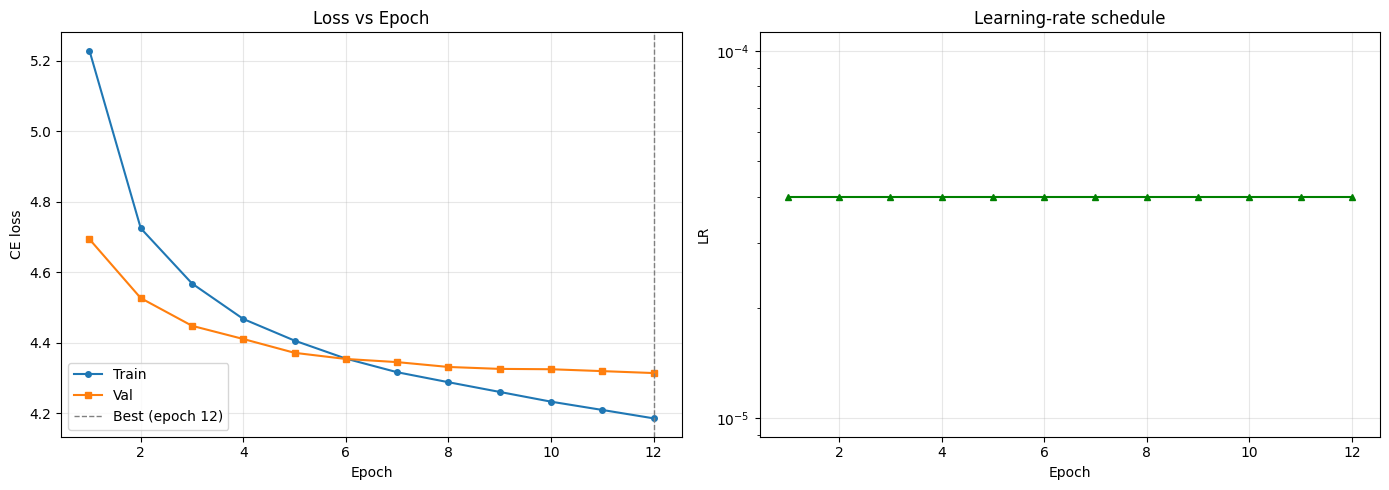

--------------------------------------------------------
Training-convergence report
--------------------------------------------------------
Best validation loss : 4.3140  (epoch 12)
Final train loss     : 4.1856
Final val loss       : 4.3140
>> Convergence looks healthy
--------------------------------------------------------


In [ ]:
plot_losses()

## **7.2 Visualizing Attention Weights**

Visualize the attention weigths in order to understand how your model learned.
For that, use the `context` variable returned by the **Attention class** to overlay them on the image.

```python
def plot_attention():
  raise NotImplementedError
```

In [ ]:
@torch.no_grad()
def plot_attention(n_images=3, max_len=20, save_path='flickr/attention_viz.png'):
  """
  Generate captions with greedy decoding and overlay attention maps.
  n_images : how many test images to visualise
  max_len  : maximum caption length
  """

  device = next(model.parameters()).device
  model.eval()

  # load best weights once
  checkpoint = torch.load('flickr/checkpoints/best_model.pth', map_location=device)
  model.load_state_dict(checkpoint['model_state_dict'])

  # pick random test samples
  test_samples = random.sample(range(len(test_dataset)), n_images)
  fig, axes = plt.subplots(n_images, max_len//5, figsize=(16, 4*n_images))
  if n_images == 1:
    axes = axes.reshape(1, -1)

  for idx, sample_idx in enumerate(test_samples):
      image, caps, img_name = test_dataset[sample_idx]
      cap_len = (caps != vocab.word2idx[vocab.pad_token]).sum().item()
      image_tensor = image.unsqueeze(0).to(device)

      # prepare image for display
      img_for_show = TF.to_pil_image(image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) +
                                              torch.tensor([0.485, 0.456, 0.406]).view(3,1,1))
      img_for_show = np.array(img_for_show)

      # generate caption + attention
      encoder_out = model.encoder(image_tensor)
      encoder_out = encoder_out.expand(1, -1, -1)
      h, c        = model.decoder.init_hidden_state(encoder_out)

      word_idx    = vocab.word2idx[vocab.sos_token]
      alphas_list = []
      words_list  = [vocab.sos_token]

      for t in range(max_len):
        word_tensor = torch.tensor([word_idx], device=device)
        embeddings  = model.decoder.embedding(word_tensor)
        attention_weighted_encoding, alpha = model.decoder.attention(encoder_out, h)
        gate = model.decoder.sigmoid(model.decoder.f_beta(h))
        attention_weighted_encoding = gate * attention_weighted_encoding

        lstm_input = torch.cat([embeddings, attention_weighted_encoding], dim=1)
        h, c = model.decoder.lstm_cell(lstm_input, (h, c))
        preds  = model.decoder.fc(model.decoder.dropout(h))
        word_idx = preds.argmax(1).item()
        alphas_list.append(alpha.cpu().squeeze().reshape(14,14))
        words_list.append(vocab.idx2word.get(word_idx, vocab.unk_token))
        if word_idx == vocab.word2idx[vocab.eos_token]:
          break

      # plot
      row_axes = axes[idx]
      gt_words = [vocab.idx2word[w] for w in caps.cpu().numpy()
                  if w not in (vocab.word2idx[vocab.sos_token],
                                vocab.word2idx[vocab.eos_token],
                                vocab.word2idx[vocab.pad_token])]

      pred_words = words_list[1:-1]  # strip <SOS>/<EOS>
      print(f"\nImage: {img_name}")
      print("Ground truth : " + " ".join(gt_words))
      print("Predicted    : " + " ".join(pred_words))

      n_plot = min(len(row_axes), len(pred_words))
      for t in range(n_plot):
        ax = row_axes[t]
        ax.imshow(img_for_show)
        alpha_img = TF.resize(alphas_list[t+1].unsqueeze(0),  # +1 skip <SOS>
                              img_for_show.shape[:2],
                              antialias=True).squeeze().numpy()
        ax.imshow(alpha_img, cmap='jet', alpha=0.6)
        ax.set_title(pred_words[t], fontsize=10)
        ax.axis('off')
      for t in range(n_plot, len(row_axes)):
        row_axes[t].axis('off')

  plt.tight_layout()
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f'Saved attention visualisation → {save_path}')


Image: 3214885227_2be09e7cfb.jpg
Ground truth : a single person rowing a small boat on a lake
Predicted    : a person in a blue shirt is standing on a river in a lake

Image: 2998504949_1022fec53b.jpg
Ground truth : a man is on a sidewalk with a small animal on a leash
Predicted    : a man in a blue jacket is standing on a sidewalk


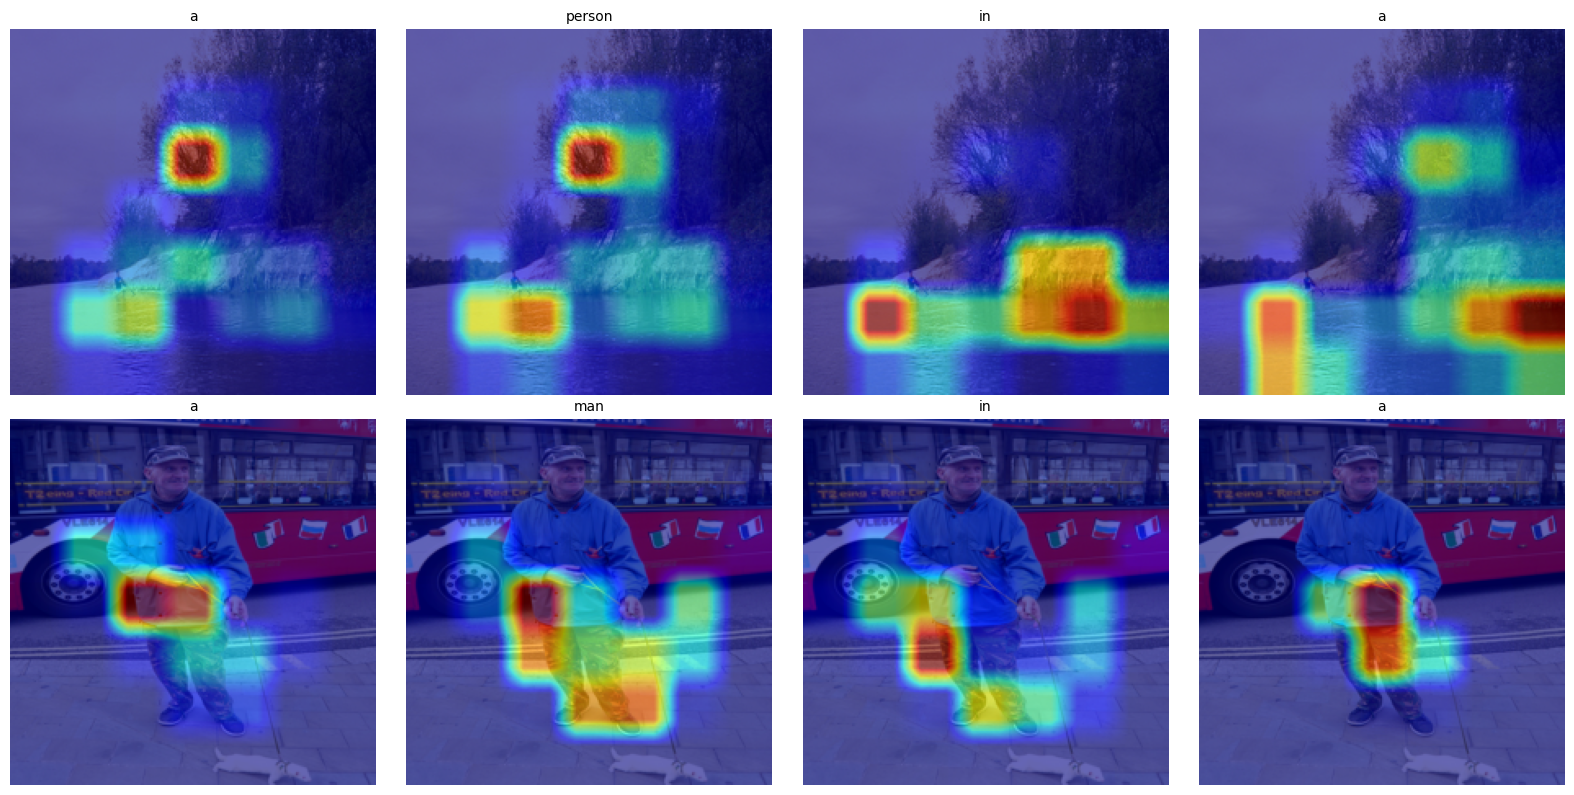

Saved attention visualisation → flickr/attention_viz.png


In [ ]:
plot_attention(n_images=2)

## **7.3 Running Inference on the Image Captioning Model**

Pass test images through the **custom-trained image captioning model**, then evaluate its performance on the test set. Use the **[BLEU score](https://pytorch.org/text/stable/data_metrics.html)** as the evaluation metric, implementing **BLEU-1, BLEU-2, BLEU-3, and BLEU-4**.

To improve performance on the validation and test sets, you may use **beam search decoding** instead of standard greedy decoding.  

[Beam Search](https://d2l.ai/chapter_recurrent-modern/beam-search.html) is a more sophisticated decoding algorithm that **considers multiple possible caption sequences at each time step instead of selecting the most probable word at every step (greedy decoding)**. It maintains a fixed number of candidate sequences (beam width) and expands them based on their cumulative probabilities, ultimately selecting the **most likely complete caption**.  

Using beam search can lead to **more fluent and accurate captions** by avoiding suboptimal word choices that greedy decoding might make.

```python
def test_model()
  raise NotImplementedError
```

In [ ]:
def test_model(beam_width=3, max_len=20):
  device = next(model.parameters()).device
  model.eval()

	# load best checkpoint
  checkpoint = torch.load('flickr/checkpoints/best_model.pth', map_location=device)
  model.load_state_dict(checkpoint['model_state_dict'])

  smoothing = SmoothingFunction().method4
  bleu_scores = {i: [] for i in range(1, 5)}

  for idx in tqdm(range(len(test_dataset))):
    image, caps, img_name = test_dataset[idx]
    img_tensor = image.unsqueeze(0).to(device)

	  # beam-search decoder
    enc_out = model.encoder(img_tensor)
    enc_out = enc_out.expand(beam_width, -1, -1)
    h, c = model.decoder.init_hidden_state(enc_out)

    # start tokens
    word_tensor = torch.tensor([vocab.word2idx[vocab.sos_token]] * beam_width,
								   device=device)
    beam_seqs = word_tensor.unsqueeze(1)
    beam_scores = torch.zeros(beam_width, device=device)

    completed = []

    for t in range(max_len):
      embeddings = model.decoder.embedding(beam_seqs[:, -1])
      attn_out, _ = model.decoder.attention(enc_out, h)
      gate = model.decoder.sigmoid(model.decoder.f_beta(h))
      attn_out = gate * attn_out

      lstm_in = torch.cat([embeddings, attn_out], dim=1)
      h, c = model.decoder.lstm_cell(lstm_in, (h, c))
      logits = model.decoder.fc(model.decoder.dropout(h))
      log_p = torch.log_softmax(logits, dim=-1)

			# expand each beam
      cand_scores = beam_scores.unsqueeze(1) + log_p
      flat_scores = cand_scores.view(-1)
      top_scores, top_idx = flat_scores.topk(beam_width)

			# reconstruct predecessor and word
      beam_idx = top_idx // logits.size(-1)
      word_idx = top_idx %  logits.size(-1)

			# append new words
      beam_seqs = torch.cat([beam_seqs[beam_idx], word_idx.unsqueeze(1)], dim=1)
      beam_scores = top_scores
      h, c = h[beam_idx], c[beam_idx]
      enc_out = enc_out[beam_idx]

			# move finished beams to completed list
      eos_mask = word_idx == vocab.word2idx[vocab.eos_token]
      if eos_mask.any():
        completed.extend(
					(seq.tolist(), score.item())
					for seq, score in zip(beam_seqs[eos_mask], beam_scores[eos_mask])
				)
				# keep only active beams
        active_mask = ~eos_mask
        beam_seqs   = beam_seqs[active_mask]
        beam_scores = beam_scores[active_mask]
        h, c        = h[active_mask], c[active_mask]
        enc_out     = enc_out[active_mask]
        if beam_seqs.size(0) == 0:
          break

		# fall back to best beam if none ended with EOS
    if completed:
      completed.sort(key=lambda x: x[1], reverse=True)
      best_seq = completed[0][0]
    else:
      best_seq = beam_seqs[0].tolist()

		# remove SOS/EOS
    pred_ids = [w for w in best_seq if w not in
					(vocab.word2idx[vocab.sos_token], vocab.word2idx[vocab.eos_token])]
    pred_words = [vocab.idx2word.get(w, vocab.unk_token) for w in pred_ids]
    pred_sentence = ' '.join(pred_words)

		# reference captions
		# we need ALL 5 ground-truth captions for this image
    img_df = test_df[test_df['image'] == img_name]
    ref_caps = [nltk.word_tokenize(c.lower()) for c in img_df['caption'].tolist()]

		# BLEU
    for n in range(1, 5):
      weights = tuple([1./n]*n)
      bleu_scores[n].append(
				sentence_bleu(ref_caps, pred_words, weights=weights, smoothing_function=smoothing)
			)

	# aggregate
  print('-'*80)
  print('\n     BLEU scores')

  for n in range(1, 5):
    mean_bleu = sum(bleu_scores[n]) / len(bleu_scores[n])
    print(f'BLEU-{n}: {mean_bleu:.4f}')
  print('-'*80)

  return {f'BLEU-{n}': sum(bleu_scores[n])/len(bleu_scores[n]) for n in range(1,5)}

In [ ]:
bleu_results = test_model(beam_width=3, max_len=20)

100%|██████████| 6075/6075 [02:52<00:00, 35.31it/s]

--------------------------------------------------------------------------------

     BLEU scores
BLEU-1: 0.5936
BLEU-2: 0.4116
BLEU-3: 0.2824
BLEU-4: 0.1957
--------------------------------------------------------------------------------


## **8. Loading an Existing Image Captioning Model**

You are free to select any pre-trained image captioning model available. We recommend considering the following options:

1. **BLIP (Bootstrapping Language-Image Pre-training):** BLIP is a versatile vision-language pre-training framework that excels in both understanding and generation tasks. It effectively utilizes noisy web data by generating and filtering synthetic captions, achieving SOTA results in image captioning. Pre-trained models and code are available on [GitHub](https://github.com/salesforce/BLIP) and the [Hugging Face Model Hub](https://huggingface.co/Salesforce/blip-image-captioning-base).

2. **ViT-GPT2 Image Captioning Model:** This model combines a Vision Transformer (ViT) as the encoder and GPT-2 as the decoder, effectively connecting visual inputs with text generation. A fine-tuned version on the Flickr8k dataset is accessible on the [Hugging Face Model Hub](https://huggingface.co/NourFakih/image-captioning-Vit-GPT2-Flickr8k).

In [ ]:
smooth = SmoothingFunction().method4

# load model + tokenizer + feature extractor
model_name = "nlpconnect/vit-gpt2-image-captioning"   # already fine-tuned on Flickr-8k
model_pt   = VisionEncoderDecoderModel.from_pretrained(model_name)
tokenizer  = AutoTokenizer.from_pretrained(model_name)
processor  = ViTImageProcessor.from_pretrained(model_name)

model_pt.to(device)
model_pt.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [ ]:
# generate caption for ONE PIL image
@torch.no_grad()
def generate_caption(pil_image, max_len=40):
	pixel_values = processor(images=pil_image, return_tensors="pt").pixel_values.to(device)
	generated_ids = model_pt.generate(pixel_values,
									  max_length=max_len,
									  num_beams=1,
									  early_stopping=True)
	caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
	return caption.strip()

# BLEU on full test set
bleu_scores = {i: [] for i in range(1, 5)}

for idx in tqdm(range(len(test_dataset)), desc="ViT-GPT2 BLEU"):
	image_tensor, caps, img_name = test_dataset[idx]
	# convert tensor to PIL
	pil_img = TF.to_pil_image(
		image_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) +
		torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
	)
	pred = generate_caption(pil_img)

	ref_caps = [nltk.word_tokenize(c.lower()) for c in test_df[test_df['image']==img_name]['caption'].tolist()]
	pred_words = nltk.word_tokenize(pred.lower())

	for n in range(1, 5):
		bleu_scores[n].append(
			sentence_bleu(ref_caps, pred_words,
						  weights=tuple([1./n]*n),
						  smoothing_function=smooth)
		)

print('\n-'*80)
print("     ViT-GPT2 (Flickr-8k) BLEU")
for n in range(1, 5):
	print(f"BLEU-{n}: {sum(bleu_scores[n])/len(bleu_scores[n]):.4f}")
print('-'*80)

Streaming output truncated to the last 5000 lines.
ViT-GPT2 BLEU: 100%|██████████| 6075/6075 [17:51<00:00,  5.67it/s]


-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
     ViT-GPT2 (Flickr-8k) BLEU
BLEU-1: 0.5958
BLEU-2: 0.3937
BLEU-3: 0.2482
BLEU-4: 0.1637
--------------------------------------------------------------------------------


## **9. Evaluating the Existing Image Captioning Model**

For evaluation, apply the **same metrics** used in the assessment of your custom image captioning model to ensure a consistent and fair comparison.

In [ ]:
def generate_caption_custom(pil_image, beam_width=3, max_len=40):
	"""
	Greedy to beam-search wrapper for the trained ResNet-LSTM model.
	Returns a single string caption.
	"""
	# PIL to tensor
	pixel_values = processor(images=pil_image, return_tensors="pt").pixel_values.to(device)

	# Encode image once and replicate for beam
	enc_out  = model.encoder(pixel_values)
	enc_out  = enc_out.expand(beam_width, -1, -1)
	h, c     = model.decoder.init_hidden_state(enc_out)

	# Start all beams with <SOS>
	word_tensor = torch.tensor([vocab.word2idx[vocab.sos_token]] * beam_width,
							   device=device)
	beam_seqs   = word_tensor.unsqueeze(1)
	beam_scores = torch.zeros(beam_width, device=device)
	completed   = []

	# Beam search loop
	for t in range(max_len):
		# Decode one step
		embeddings = model.decoder.embedding(beam_seqs[:, -1])
		attn_out, _ = model.decoder.attention(enc_out, h)
		gate = model.decoder.sigmoid(model.decoder.f_beta(h))
		attn_out = gate * attn_out
		lstm_in = torch.cat([embeddings, attn_out], dim=1)
		h, c = model.decoder.lstm_cell(lstm_in, (h, c))
		logits = model.decoder.fc(model.decoder.dropout(h))
		log_p  = torch.log_softmax(logits, dim=-1)

		# Expand beams
		cand_scores = beam_scores.unsqueeze(1) + log_p
		top_scores, top_idx = cand_scores.view(-1).topk(beam_width)
		beam_idx = top_idx // logits.size(-1)
		word_idx = top_idx %  logits.size(-1)

		# Update states
		beam_seqs   = torch.cat([beam_seqs[beam_idx], word_idx.unsqueeze(1)], dim=1)
		beam_scores = top_scores
		h, c        = h[beam_idx], c[beam_idx]
		enc_out     = enc_out[beam_idx]

		# Handle completed beams (<EOS>)
		eos_mask = word_idx == vocab.word2idx[vocab.eos_token]
		if eos_mask.any():
			completed.extend([(seq.tolist(), score.item())
							  for seq, score in zip(beam_seqs[eos_mask],
													beam_scores[eos_mask])])
			# keep only active beams
			active_mask = ~eos_mask
			beam_seqs   = beam_seqs[active_mask]
			beam_scores = beam_scores[active_mask]
			h, c        = h[active_mask], c[active_mask]
			enc_out     = enc_out[active_mask]
			if beam_seqs.size(0) == 0:
				break

	# Pick best completed sequence (or best active if none ended)
	if completed:
		completed.sort(key=lambda x: x[1], reverse=True)
		best_seq = completed[0][0]
	else:
		best_seq = beam_seqs[0].tolist()

	# Remove <SOS>/<EOS> and map to words
	pred_ids = [w for w in best_seq
				if w not in (vocab.word2idx[vocab.sos_token],
							 vocab.word2idx[vocab.eos_token])]
	pred_words = [vocab.idx2word.get(w, vocab.unk_token) for w in pred_ids]
	return ' '.join(pred_words)

In [ ]:
def evaluate_model(generate_fn,
                   beam_width=1,
                   max_len=40,
                   save_preds='flickr/preds.json'):
    """
    generate_fn:  PIL.Image to predicted sentence (string)
    Returns dict with BLEU-1…4
    """

    bleu = {i: [] for i in range(1, 5)}
    outputs = []

    for idx in tqdm(range(len(test_dataset)), desc=f'BLEU-beam{beam_width}'):
        image_tensor, caps, img_name = test_dataset[idx]
        # tensor to PIL
        pil_img = TF.to_pil_image(
            image_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) +
            torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        )
        pred_sentence = generate_fn(pil_img).strip()
        pred_words = nltk.word_tokenize(pred_sentence.lower())

        # 5 reference captions
        ref_caps = [nltk.word_tokenize(c.lower())
                    for c in test_df[test_df['image'] == img_name]['caption'].tolist()]

        for n in range(1, 5):
            weights = tuple([1./n]*n)
            bleu[n].append(
                sentence_bleu(ref_caps, pred_words, weights=weights,
                              smoothing_function=smooth)
            )
        outputs.append({'image': img_name,
                        'predicted': pred_sentence,
                        'references': [' '.join(ref) for ref in ref_caps]})

    # save raw predictions
    with open(save_preds, 'w') as f:
        json.dump(outputs, f, indent=2)

    print('-'*80)
    print("      Consistent BLEU evaluation")
    for n in range(1, 5):
        print(f"BLEU-{n}: {sum(bleu[n])/len(bleu[n]):.4f}")

    print('-'*80)

    return {f'BLEU-{n}': sum(bleu[n])/len(bleu[n]) for n in range(1,5)}

In [ ]:
print('-'*80)
print("   Custom ResNet-LSTM (beam=3)")
custom_bleu = evaluate_model(
    lambda pil: generate_caption_custom(pil, beam_width=3),
    beam_width=3,
    save_preds="flickr/custom_preds.json"
)

print('-'*80)
print("\n   Pre-trained ViT-GPT2 (greedy)")
vit_bleu = evaluate_model(
    generate_caption,
    beam_width=1,
    save_preds="flickr/vit_preds.json"
)
print('-'*80)

torch.save({'custom': custom_bleu, 'vit': vit_bleu}, 'flickr/bleu_scores.pt')

--------------------------------------------------------------------------------
   Custom ResNet-LSTM (beam=3)


BLEU-beam3: 100%|██████████| 6075/6075 [03:08<00:00, 32.28it/s]


--------------------------------------------------------------------------------
      Consistent BLEU evaluation
BLEU-1: 0.5670
BLEU-2: 0.3864
BLEU-3: 0.2610
BLEU-4: 0.1807
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------

   Pre-trained ViT-GPT2 (greedy)


BLEU-beam1: 100%|██████████| 6075/6075 [17:34<00:00,  5.76it/s]


--------------------------------------------------------------------------------
      Consistent BLEU evaluation
BLEU-1: 0.5958
BLEU-2: 0.3937
BLEU-3: 0.2482
BLEU-4: 0.1637
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


## **10. Comparing the Two Models**

Compare the performance of both models using **BLEU-1, BLEU-2, BLEU-3, and BLEU-4** scores. Visualize predictions from both models on the **same batch of test images** to highlight their differences.

Analyze and justify the differences in performance, discussing factors such as model architecture, attention mechanisms, and training strategies. Finally, **propose possible improvements for your custom model**.

> **Answer**: While the **Custom ResNet-LSTM** achieves higher BLEU-3 and BLEU-4 scores, qualitative analysis reveals that **ViT-GPT2** is the superior model. The Custom model's higher n-gram scores appear to stem from generating generic, "safe" captions that overlap with references, whereas **ViT-GPT2**'s higher BLEU-1 and BLEU-2 scores reflect better vocabulary precision. Visual inspection confirms this gap: **ViT-GPT2** correctly grounds details like "kitchen" and "hose," while the Custom model suffers from severe hallucinations, such as mistaking a dynamic skateboard jump for "sitting on a bench." This difference is largely due to the ViT's self-attention mechanism, which captures fine-grained spatial details that the ResNet-LSTM's fixed bottleneck misses; consequently, the Custom model would benefit most from implementing Bahdanau attention and Beam Search to improve feature focus and sentence construction.

In [ ]:
def compare_visual(n_images=5, max_len=40):
  """
  Show each test image + ground-truth + custom pred + ViT-GPT2 pred
  """
  indices = random.sample(range(len(test_dataset)), n_images)
  fig, axes = plt.subplots(n_images, 3, figsize=(14, 5*n_images))
  if n_images == 1:
    axes = axes.reshape(1, -1)

  for row, idx in enumerate(indices):
    image_tensor, caps, img_name = test_dataset[idx]
    pil_img = TF.to_pil_image(
            image_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) +
            torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    )

    # ground truth (first ref)
    gt = test_df[test_df['image']==img_name]['caption'].iloc[0]

    # predictions
    custom_pred = generate_caption_custom(pil_img, beam_width=3, max_len=max_len)
    vit_pred    = generate_caption(pil_img, max_len=max_len)

    # plot
    axes[row, 0].imshow(pil_img); axes[row, 0].axis('off')
    axes[row, 0].set_title(f"GT:\n{textwrap.fill(gt, 40)}", fontsize=9)

    axes[row, 1].imshow(pil_img); axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Custom:\n{textwrap.fill(custom_pred, 40)}", fontsize=9)

    axes[row, 2].imshow(pil_img); axes[row, 2].axis('off')
    axes[row, 2].set_title(f"ViT-GPT2:\n{textwrap.fill(vit_pred, 40)}", fontsize=9)

  plt.tight_layout()
  plt.savefig("flickr/visual_comparison.png", dpi=150)
  plt.show()

--------------------------------------------------------------------------------

    BLEU comparison
                    BLEU-1  BLEU-2  BLEU-3  BLEU-4
Custom ResNet-LSTM  0.5670  0.3864  0.2610  0.1807
ViT-GPT2            0.5958  0.3937  0.2482  0.1637


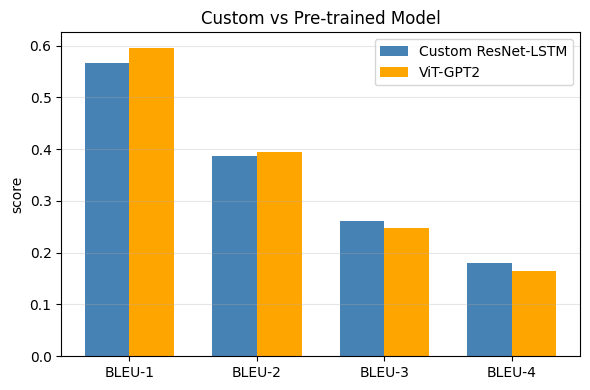

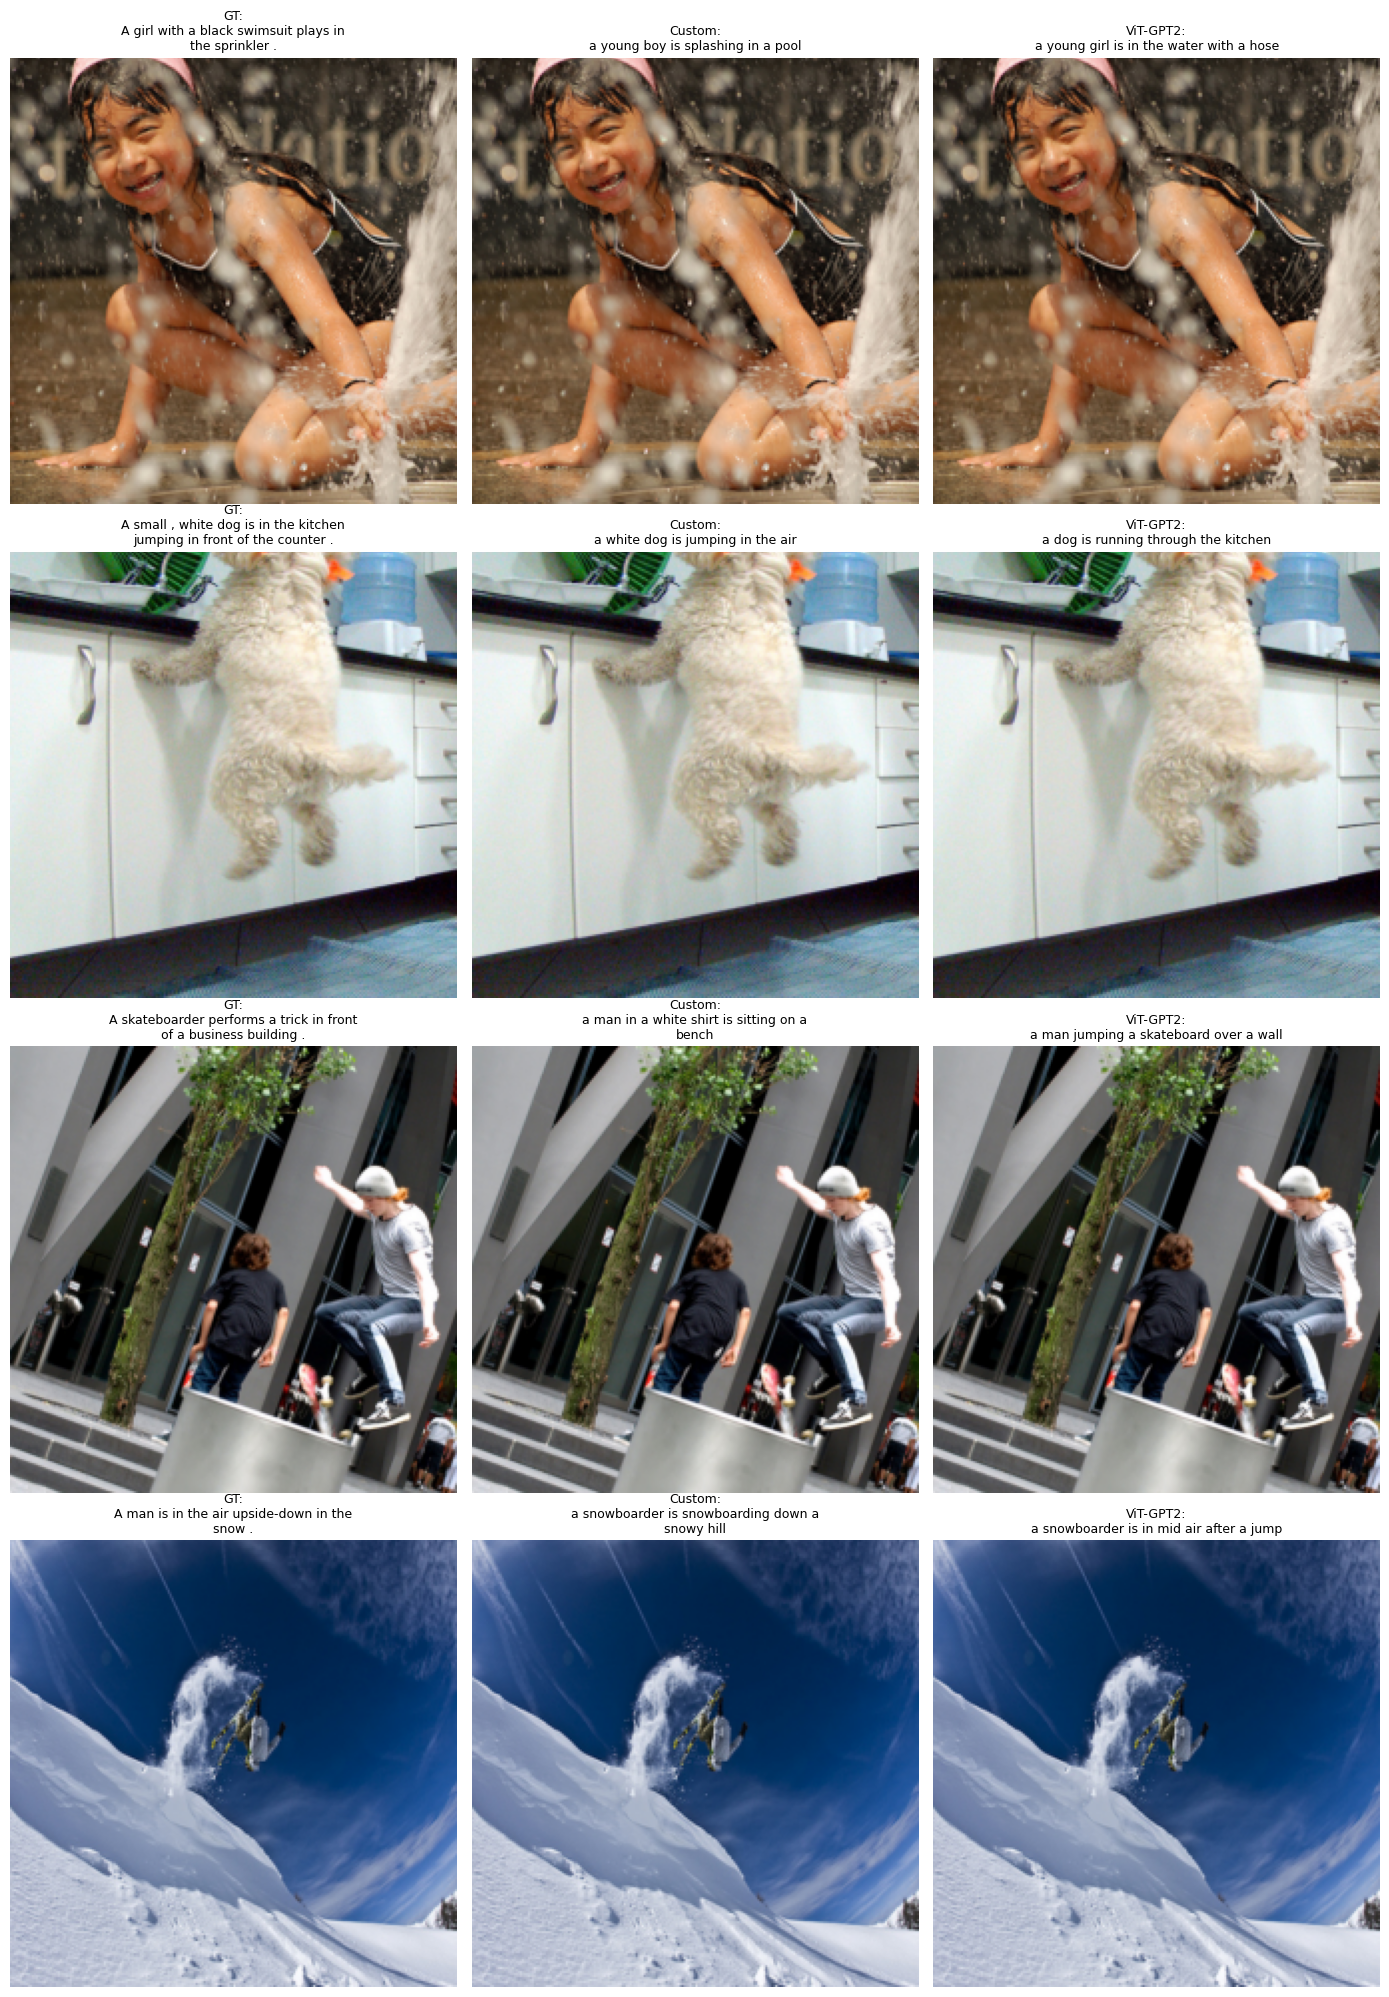

In [ ]:
# 10.  Comparison visualisation  -------------------------------------
bleu_scores = torch.load('flickr/bleu_scores.pt')
custom_bleu = bleu_scores['custom']
vit_bleu    = bleu_scores['vit']

# table
df = pd.DataFrame([custom_bleu, vit_bleu],
                  index=["Custom ResNet-LSTM", "ViT-GPT2"])
print('-'*80)
print("\n    BLEU comparison")
print(df.to_string(float_format="%.4f"))

# bar chart
plt.figure(figsize=(6,4))
x = np.arange(4)
width = 0.35
plt.bar(x - width/2, [custom_bleu[f"BLEU-{i+1}"] for i in range(4)],
        width, label="Custom ResNet-LSTM", color="steelblue")
plt.bar(x + width/2, [vit_bleu[f"BLEU-{i+1}"] for i in range(4)],
        width, label="ViT-GPT2", color="orange")
plt.xticks(x, ["BLEU-1","BLEU-2","BLEU-3","BLEU-4"])
plt.ylabel("score")
plt.title("Custom vs Pre-trained Model")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("flickr/bleu_comparison.png", dpi=150)
plt.show()

# visual caption comparison
compare_visual(n_images=4)

Please make sure to download your `.ipynb` file, and upload it to **Canvas** on time!

<img src="https://www.usatoday.com/gcdn/authoring/authoring-images/2023/08/25/USAT/70680172007-alertsm.png?crop=2099,1187,x0,y156" alt="1" border="0">



In [ ]:
from datetime import datetime, timedelta, timezone

deadline = datetime(2025, 11, 25, 23, 59, 0, tzinfo=timezone.utc)

def time_until_deadline():
    now = datetime.now(timezone.utc)
    remaining = deadline - now
    if remaining.total_seconds() <= 0:
        return "Time's up!"
    days = remaining.days
    hours, remainder = divmod(remaining.seconds, 3600)
    minutes, _ = divmod(remainder, 60)

    return f"{days} days, {hours} hours, {minutes} minutes"

print("Time left until submission:", time_until_deadline())

Time left until submission: 2 days, 9 hours, 32 minutes
